In [13]:

import requests
import pandas as pd
from datetime import datetime, timezone
import time

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ————————————————————————————————
# 0) Mapeo manual de URLs a nombres de película
# ————————————————————————————————
movie_mapping = {
    "https://www.reddit.com/r/movies/comments/195s51j/eternal_sunshine_of_the_spotless_mind.json": "eternal_sunshine_of_the_spotless_mind",
    "https://www.reddit.com/r/TrueFilm/comments/15gt4gh/mr_nobody_2009.json": "mr_nobody",
    "https://www.reddit.com/r/movies/comments/2ljk71/official_discussion_interstellar_wide_release.json": "interestelar",
    "https://www.reddit.com/r/movies/comments/17cu9sr/moon_2009_is_the_worst_movie_i_have_ever_watched.json": "moon",
    "https://www.reddit.com/r/movies/comments/132zxlu/ex_machina_is_a_wonderful_movie_with_amazing.json": "ex_machina",
    "https://www.reddit.com/r/netflix/comments/1b0ibe9/is_love_death_robots_is_worth_watching.json": "love_death_robots",
    "https://www.reddit.com/r/movies/comments/ol7bn1/many_people_missed_the_point_of_500_days_of.json": "500_days_with_summer",
    "https://www.reddit.com/r/moviecritic/comments/1hrx15y/her_2013_was_set_in_2025_drop_your_thoughts_about.json": "her"
}

# ————————————————————————————————
# 1) Scraping de comentarios de Reddit
# ————————————————————————————————
urls = list(movie_mapping.keys())
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json, text/plain, */*",
}
comentarios = []

def extraer_comentarios(lista, nivel, base, titulo):
    if not lista:
        return
    for item in lista:
        if item.get("kind") == "t1":
            d = item["data"]
            texto = d.get("body", "")
            if texto and texto not in ("[deleted]", "[removed]"):
                comentarios.append({
                    "Movie": titulo,
                    "URL": base.replace(".json", ""),
                    "Fecha UTC": datetime.fromtimestamp(
                        d.get("created_utc", 0), tz=timezone.utc
                    ).strftime('%Y-%m-%d %H:%M:%S'),
                    "Autor": d.get("author", "[deleted]"),
                    "Comentario": texto,
                    "Puntaje": d.get("score", 0),
                    "Nivel": nivel
                })
            rep = d.get("replies")
            if isinstance(rep, dict):
                hijos = rep.get("data", {}).get("children", [])
                extraer_comentarios(hijos, nivel + 1, base, titulo)

for i, url in enumerate(urls):
    if i > 0:
        time.sleep(2)
    try:
        r = requests.get(url, headers=headers, params={'raw_json': 1}, timeout=30)
        r.raise_for_status()
        data = r.json()
        titulo = movie_mapping[url]
        extraer_comentarios(data[1]["data"]["children"], 1, url, titulo)
        print(f"Procesado {i+1}/{len(urls)} → {len(comentarios)} comentarios")
    except Exception as e:
        print(f"Error en URL {i+1}: {e}")


Procesado 1/8 → 193 comentarios
Procesado 2/8 → 225 comentarios
Procesado 3/8 → 418 comentarios
Procesado 4/8 → 565 comentarios
Procesado 5/8 → 701 comentarios
Procesado 6/8 → 892 comentarios
Procesado 7/8 → 1090 comentarios
Procesado 8/8 → 1234 comentarios


In [14]:
df = pd.read_csv("Comentarios_Clusterizados_EDA_ok.csv")
df.head()

,Movie,URL,Fecha UTC,Autor,Comentario,Puntaje,Nivel,NumChars,NumWords,Polarity,Subjectivity,Cluster
0,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-08-09 02:42:55,RealNoodles221,wow,14,3,3,1,0.100000,1.000000,4
1,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-11-19 09:33:38,Zestyclose-Sir-851,Agreed! Lovely and astounding ending!,5,2,37,5,0.625000,0.875000,4
2,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-11-20 01:23:04,Confident-City-3108,"Yes! It hit me too, look on te other side of a...",3,2,163,35,-0.141667,0.680556,4
3,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2025-03-14 13:56:34,ilovetyrol,"Yes. That final ""okay."" Best ending to a won...",3,2,59,10,0.625000,0.700000,4
4,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-01-13 17:01:53,[deleted],Yeah. The scene where he can’t accept his deci...,39,2,95,18,0.500000,1.000000,4


In [15]:
df.shape

(816, 12)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie         816 non-null    object 
 1   URL           816 non-null    object 
 2   Fecha UTC     816 non-null    object 
 3   Autor         816 non-null    object 
 4   Comentario    816 non-null    object 
 5   Puntaje       816 non-null    int64  
 6   Nivel         816 non-null    int64  
 7   NumChars      816 non-null    int64  
 8   NumWords      816 non-null    int64  
 9   Polarity      816 non-null    float64
 10  Subjectivity  816 non-null    float64
 11  Cluster       816 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 76.6+ KB


In [17]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Movie,816,8,love_death_robots,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
URL,816,8,https://www.reddit.com/r/netflix/comments/1b0i...,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha UTC,816,815,2024-02-26 15:13:32,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Autor,816,595,[deleted],105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comentario,816,807,Yes,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Puntaje,816.0,NaN,NaN,NaN,7.503676,12.480954,-33.0,1.0,2.0,8.0,74.0
Nivel,816.0,NaN,NaN,NaN,2.113971,1.546181,1.0,1.0,2.0,3.0,10.0
NumChars,816.0,NaN,NaN,NaN,130.068627,113.079624,1.0,43.0,97.5,175.25,489.0
NumWords,816.0,NaN,NaN,NaN,23.765931,20.447458,1.0,8.0,18.0,32.0,91.0
Polarity,816.0,NaN,NaN,NaN,0.147122,0.240904,-0.428571,0.0,0.109697,0.3,0.725


In [18]:
#Looking for null values
df.isna().sum()

Movie           0
URL             0
Fecha UTC       0
Autor           0
Comentario      0
Puntaje         0
Nivel           0
NumChars        0
NumWords        0
Polarity        0
Subjectivity    0
Cluster         0
dtype: int64

In [19]:
# Identificación y tratamiento de outliers usando el método del rango intercuartílico (IQR)
def tratar_outliers(df, columnas):
    df_out = df.copy()
    for col in columnas:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        # Opciones: eliminar o limitar (winsorizar)
        # Aquí: winsorizamos (capamos los valores extremos)
        df_out[col] = df_out[col].clip(lower, upper)
    return df_out

# Selecciona las columnas numéricas relevantes
columnas_numericas = ['NumChars', 'NumWords', 'Polarity', 'Subjectivity', 'Puntaje']

# Aplica el tratamiento de outliers
df_sin_outliers = tratar_outliers(df, columnas_numericas)

# Puedes comparar antes y después, por ejemplo:
df[columnas_numericas].describe(), df_sin_outliers[columnas_numericas].describe()

(         NumChars    NumWords    Polarity  Subjectivity     Puntaje
 count  816.000000  816.000000  816.000000    816.000000  816.000000
 mean   130.068627   23.765931    0.147122      0.451673    7.503676
 std    113.079624   20.447458    0.240904      0.288351   12.480954
 min      1.000000    1.000000   -0.428571      0.000000  -33.000000
 25%     43.000000    8.000000    0.000000      0.250000    1.000000
 50%     97.500000   18.000000    0.109697      0.500000    2.000000
 75%    175.250000   32.000000    0.300000      0.658844    8.000000
 max    489.000000   91.000000    0.725000      1.000000   74.000000,
          NumChars    NumWords    Polarity  Subjectivity     Puntaje
 count  816.000000  816.000000  816.000000    816.000000  816.000000
 mean   126.804534   23.207108    0.147122      0.451673    5.494485
 std    104.543078   18.985432    0.240904      0.288351    6.506130
 min      1.000000    1.000000   -0.428571      0.000000   -9.500000
 25%     43.000000    8.000000   

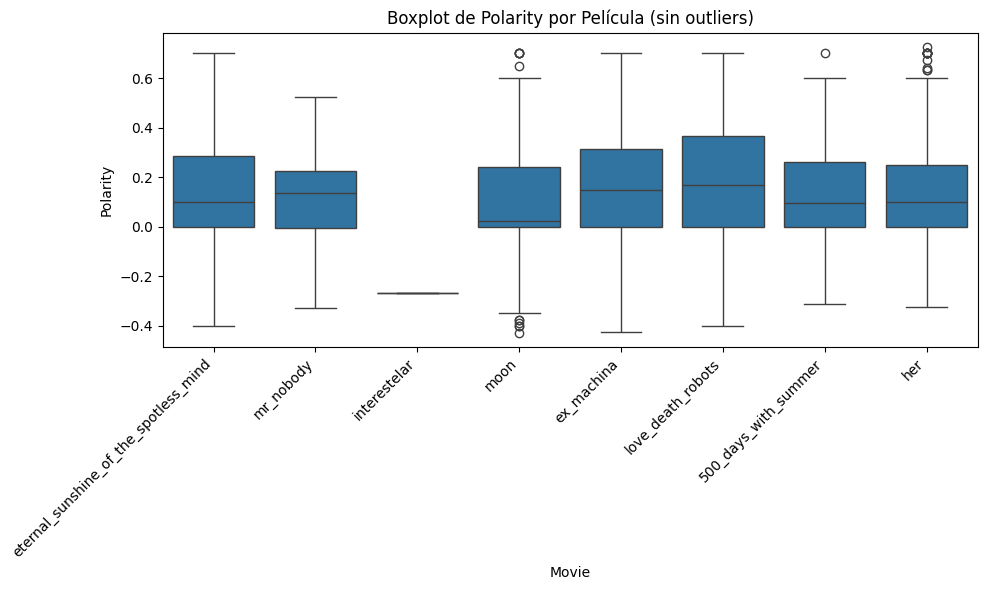

In [20]:
# Boxplot de la variable 'Polarity' (sin outliers) para cada película
plt.figure(figsize=(10, 6))
sns.boxplot(x='Movie', y='Polarity', data=df_sin_outliers)
plt.title('Boxplot de Polarity por Película (sin outliers)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
df_sin_outliers.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Movie,816,8,love_death_robots,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
URL,816,8,https://www.reddit.com/r/netflix/comments/1b0i...,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha UTC,816,815,2024-02-26 15:13:32,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Autor,816,595,[deleted],105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comentario,816,807,Yes,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Puntaje,816.0,NaN,NaN,NaN,5.494485,6.50613,-9.5,1.0,2.0,8.0,18.5
Nivel,816.0,NaN,NaN,NaN,2.113971,1.546181,1.0,1.0,2.0,3.0,10.0
NumChars,816.0,NaN,NaN,NaN,126.804534,104.543078,1.0,43.0,97.5,175.25,373.625
NumWords,816.0,NaN,NaN,NaN,23.207108,18.985432,1.0,8.0,18.0,32.0,68.0
Polarity,816.0,NaN,NaN,NaN,0.147122,0.240904,-0.428571,0.0,0.109697,0.3,0.725


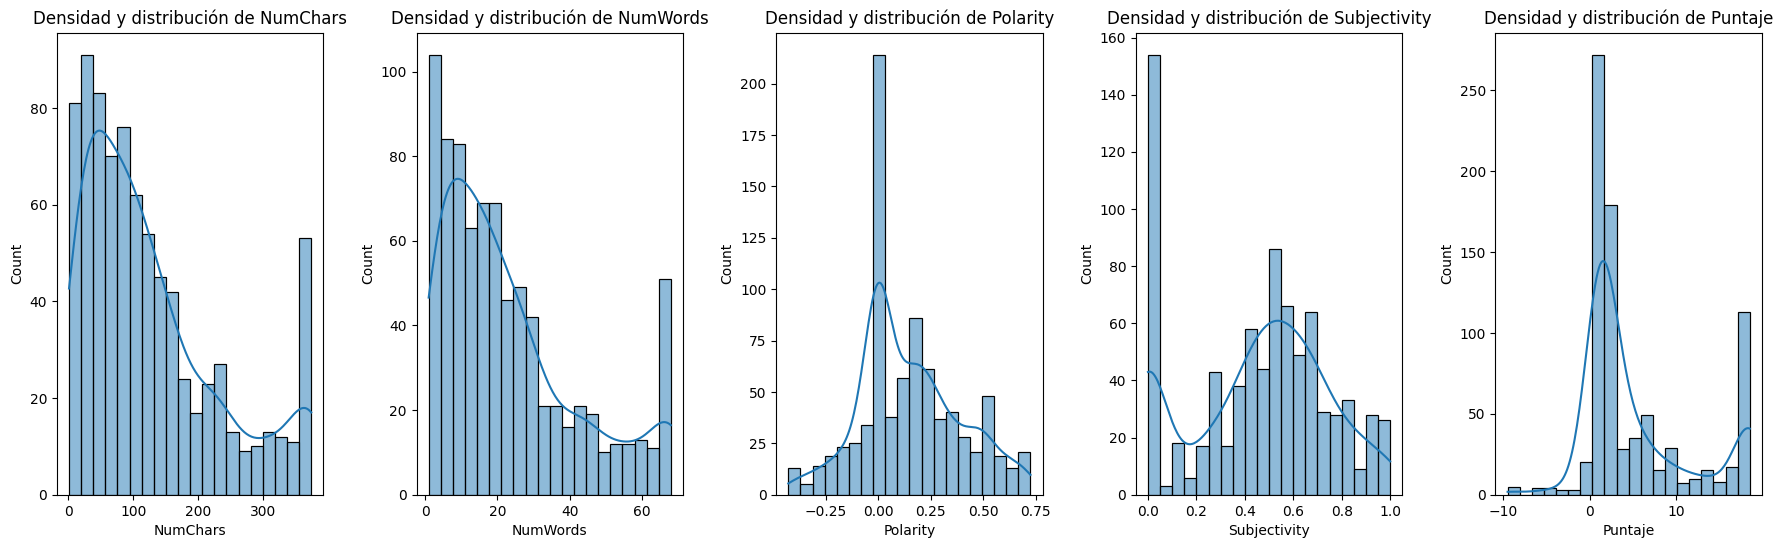

In [22]:
# Estimación de densidad de valores usando histplot (KDE)
plt.figure(1, figsize=(22, 6))
feature_list = columnas_numericas
pos = 1
for i in feature_list:
    plt.subplot(1, len(feature_list), pos)
    plt.subplots_adjust(hspace=0.5, wspace=0.35)  # Aumenta wspace para más separación
    sns.histplot(df_sin_outliers[i], bins=20, kde=True)
    plt.title(f'Densidad y distribución de {i}')
    pos += 1
plt.show()

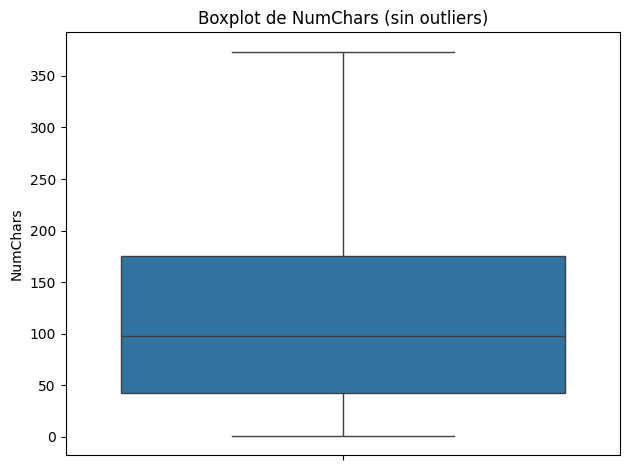

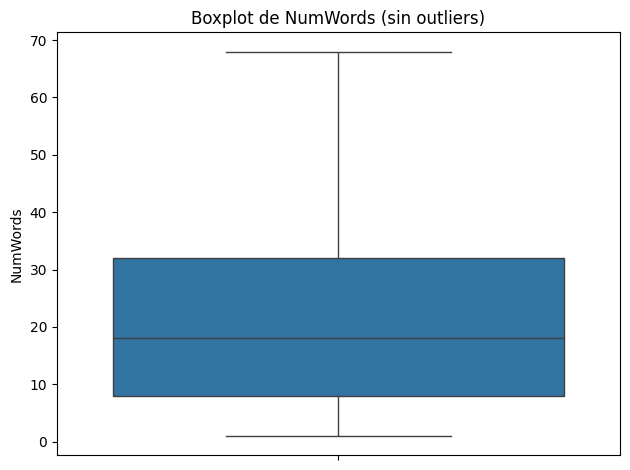

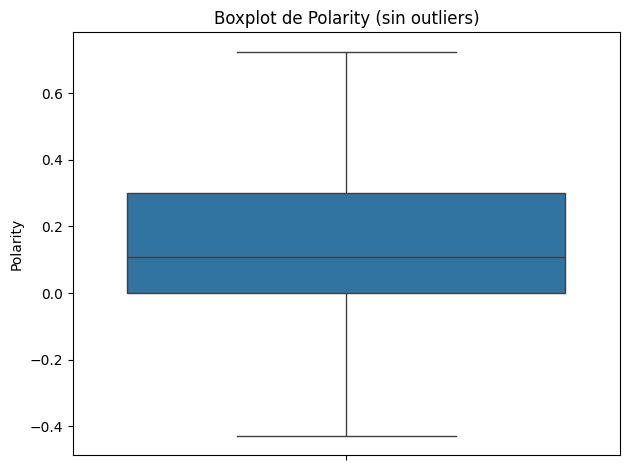

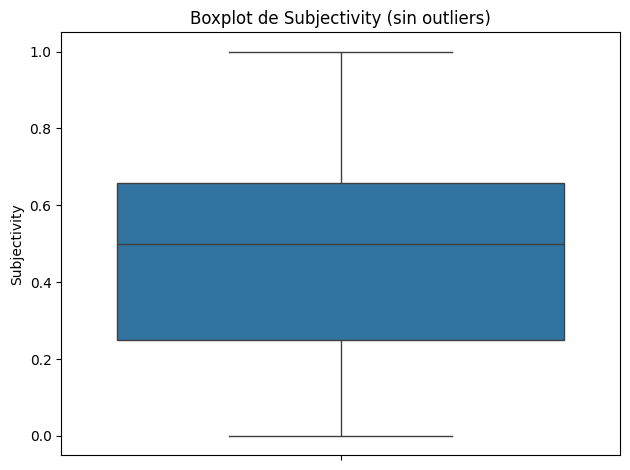

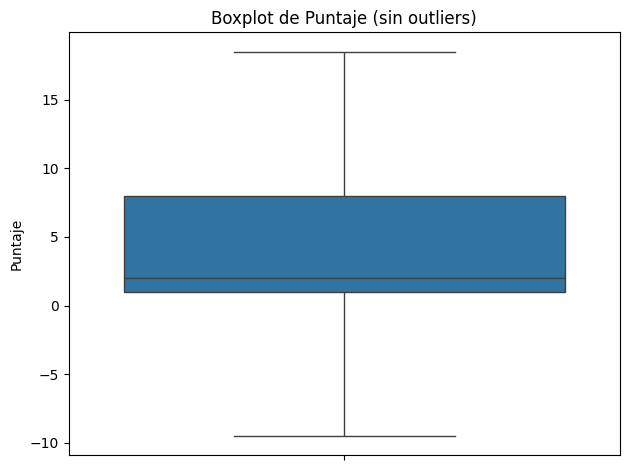

In [23]:
# Boxplot de las columnas numéricas después de tratar outliers
for col in columnas_numericas:
    plt.figure()
    sns.boxplot(y=df_sin_outliers[col])
    plt.title(f"Boxplot de {col} (sin outliers)")
    plt.tight_layout()
    plt.show()

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

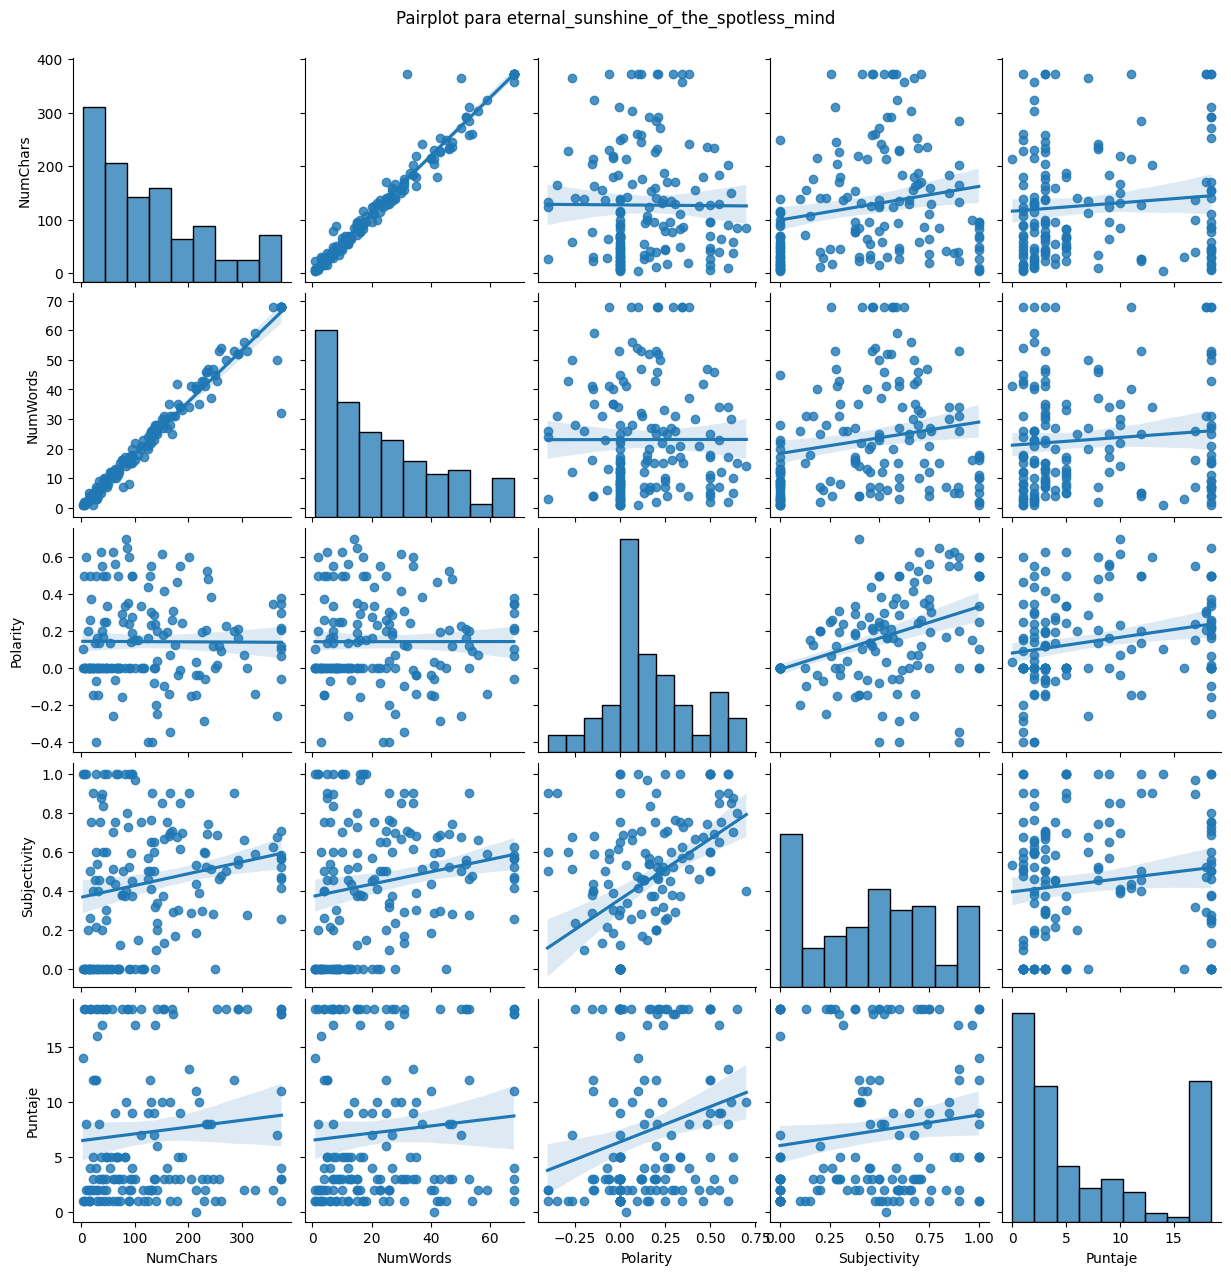

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

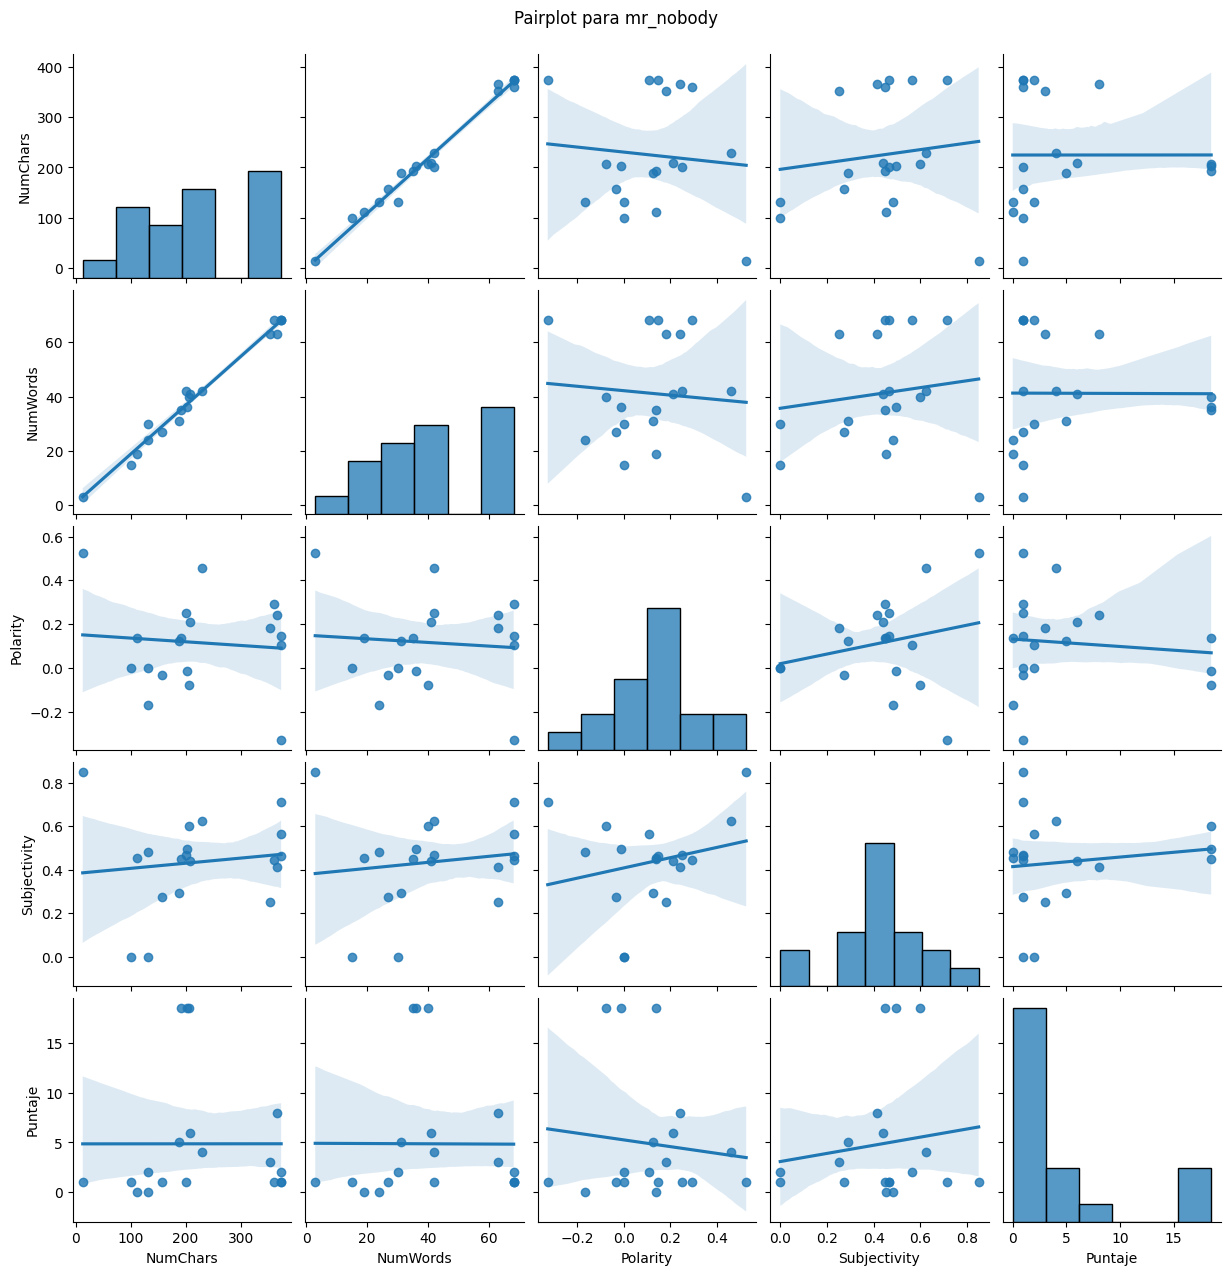

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

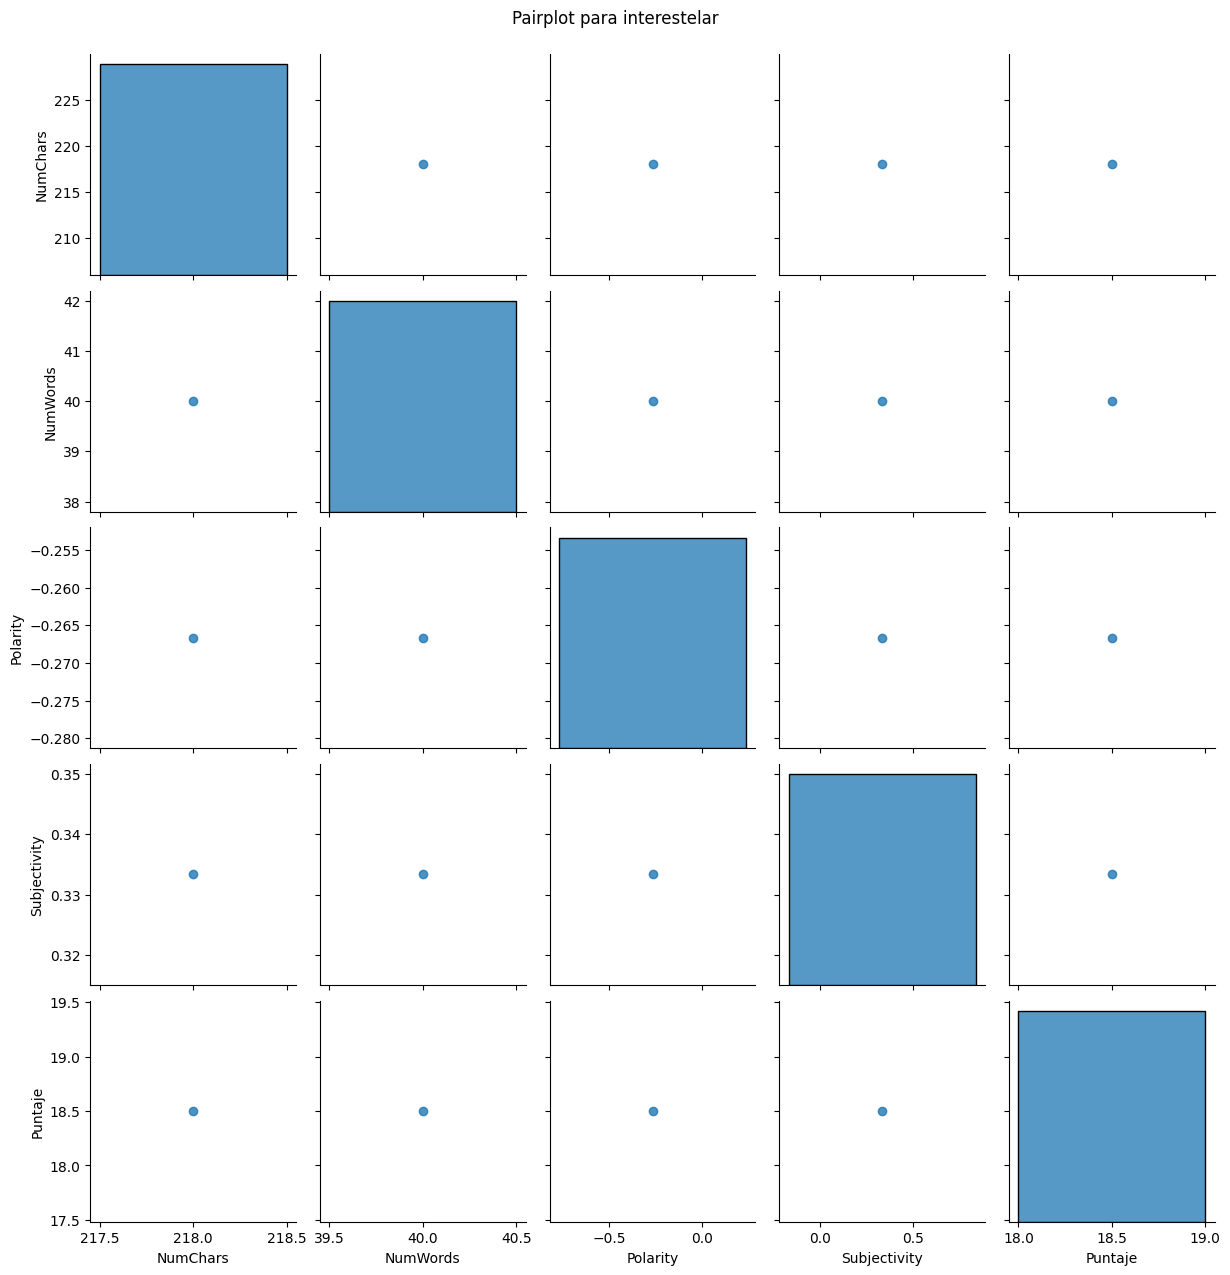

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

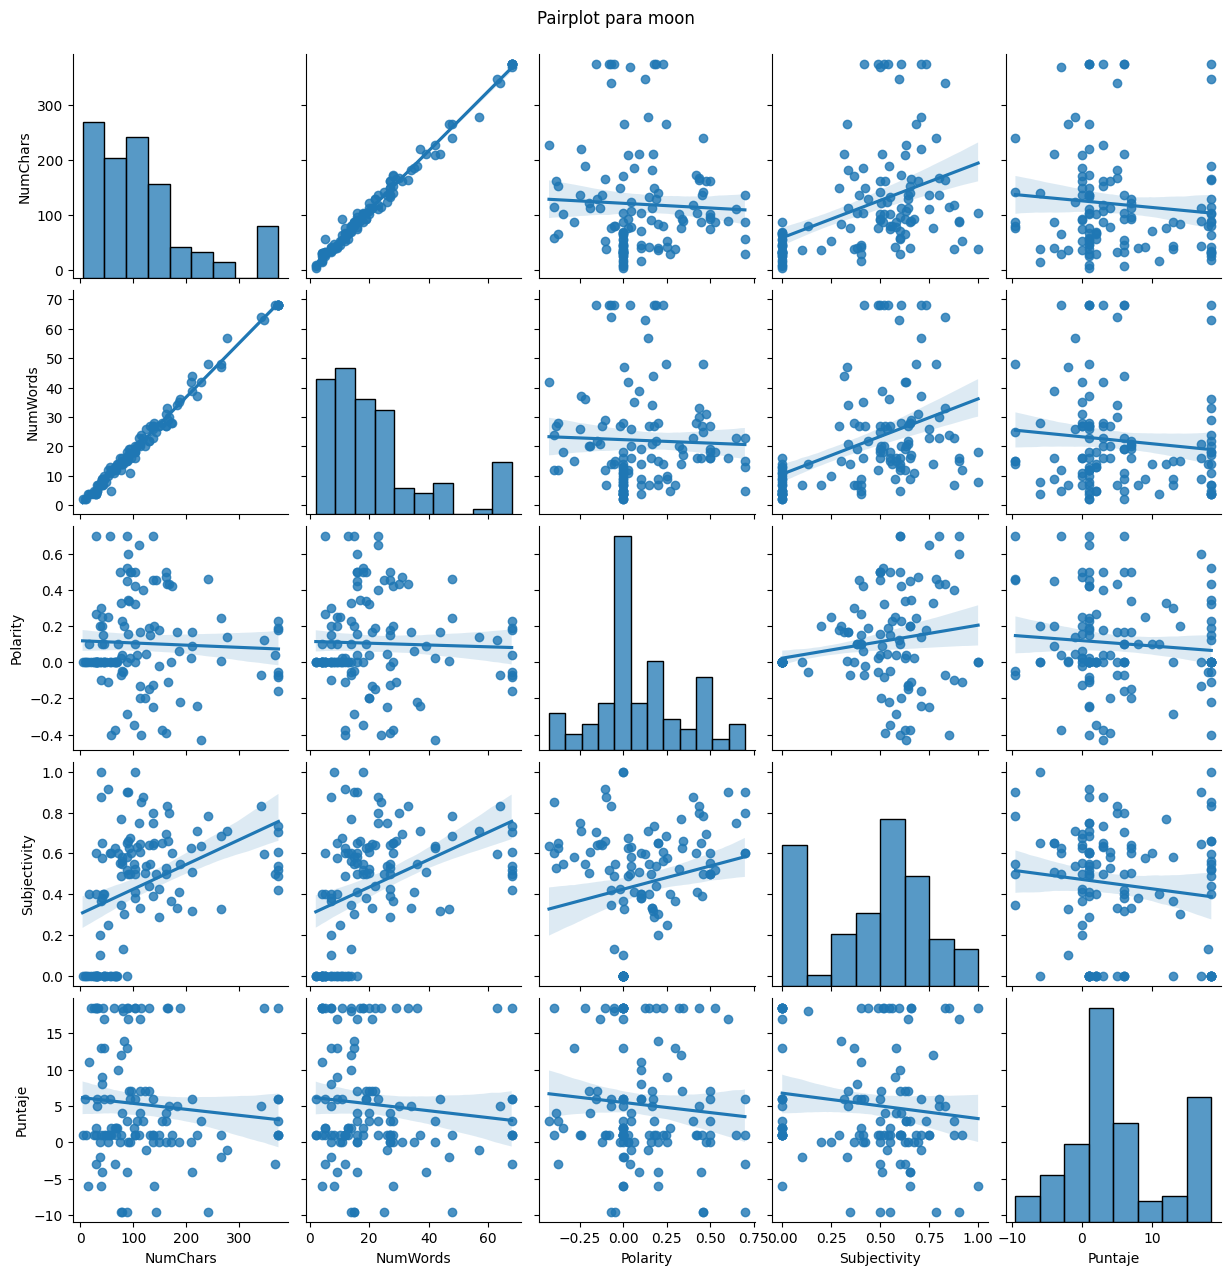

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

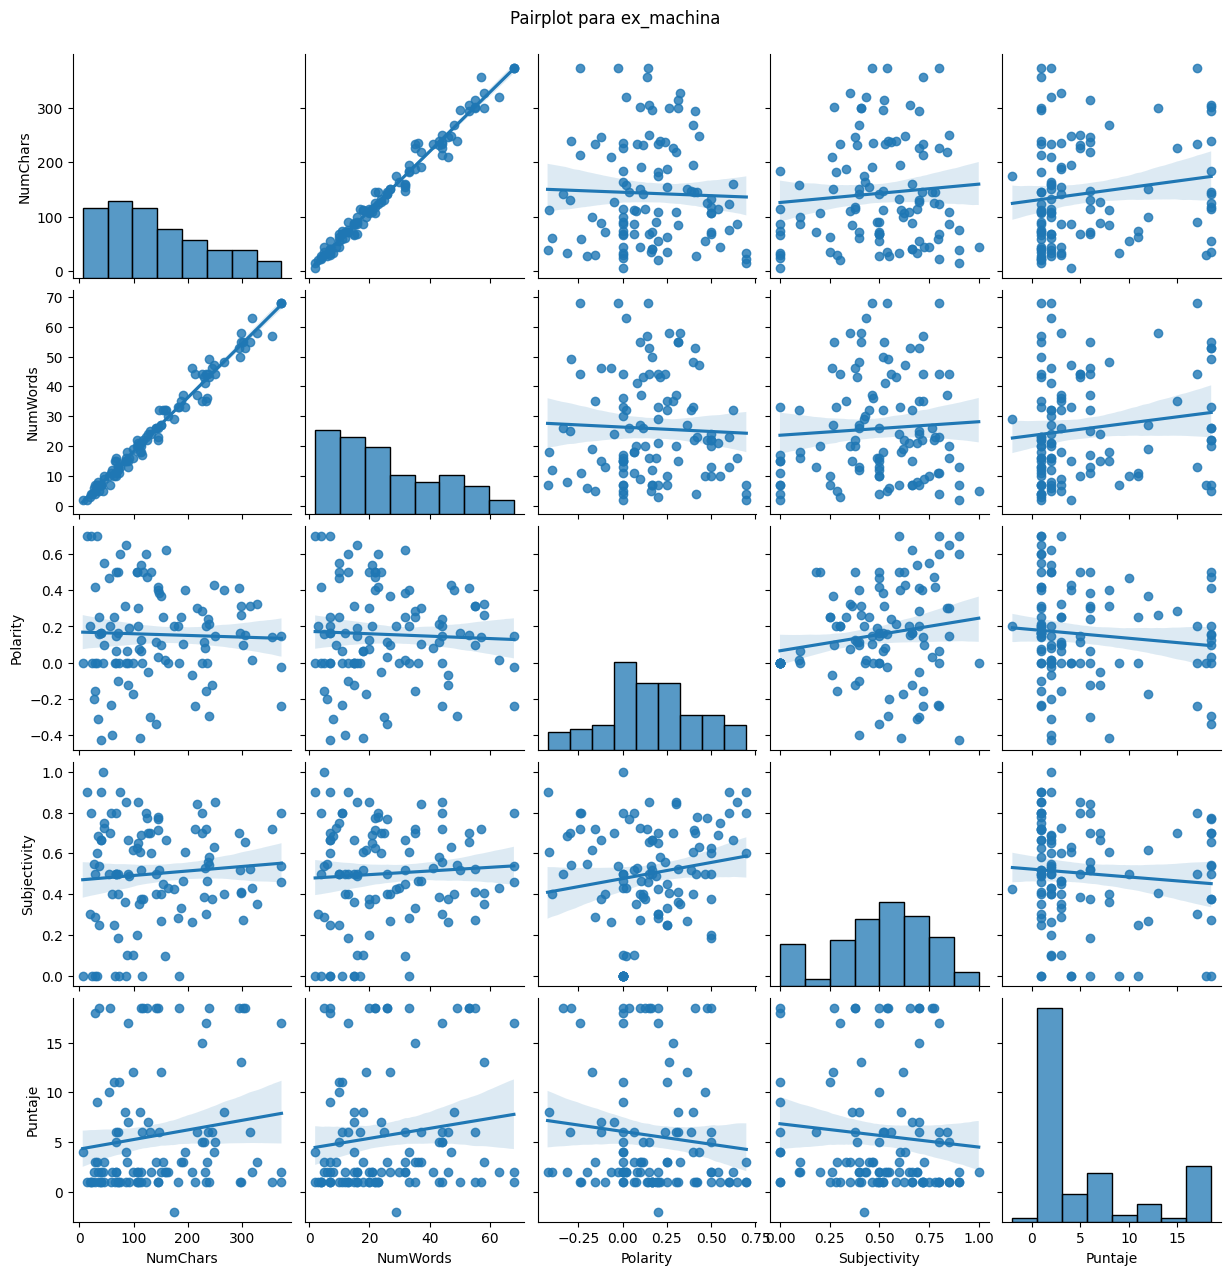

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

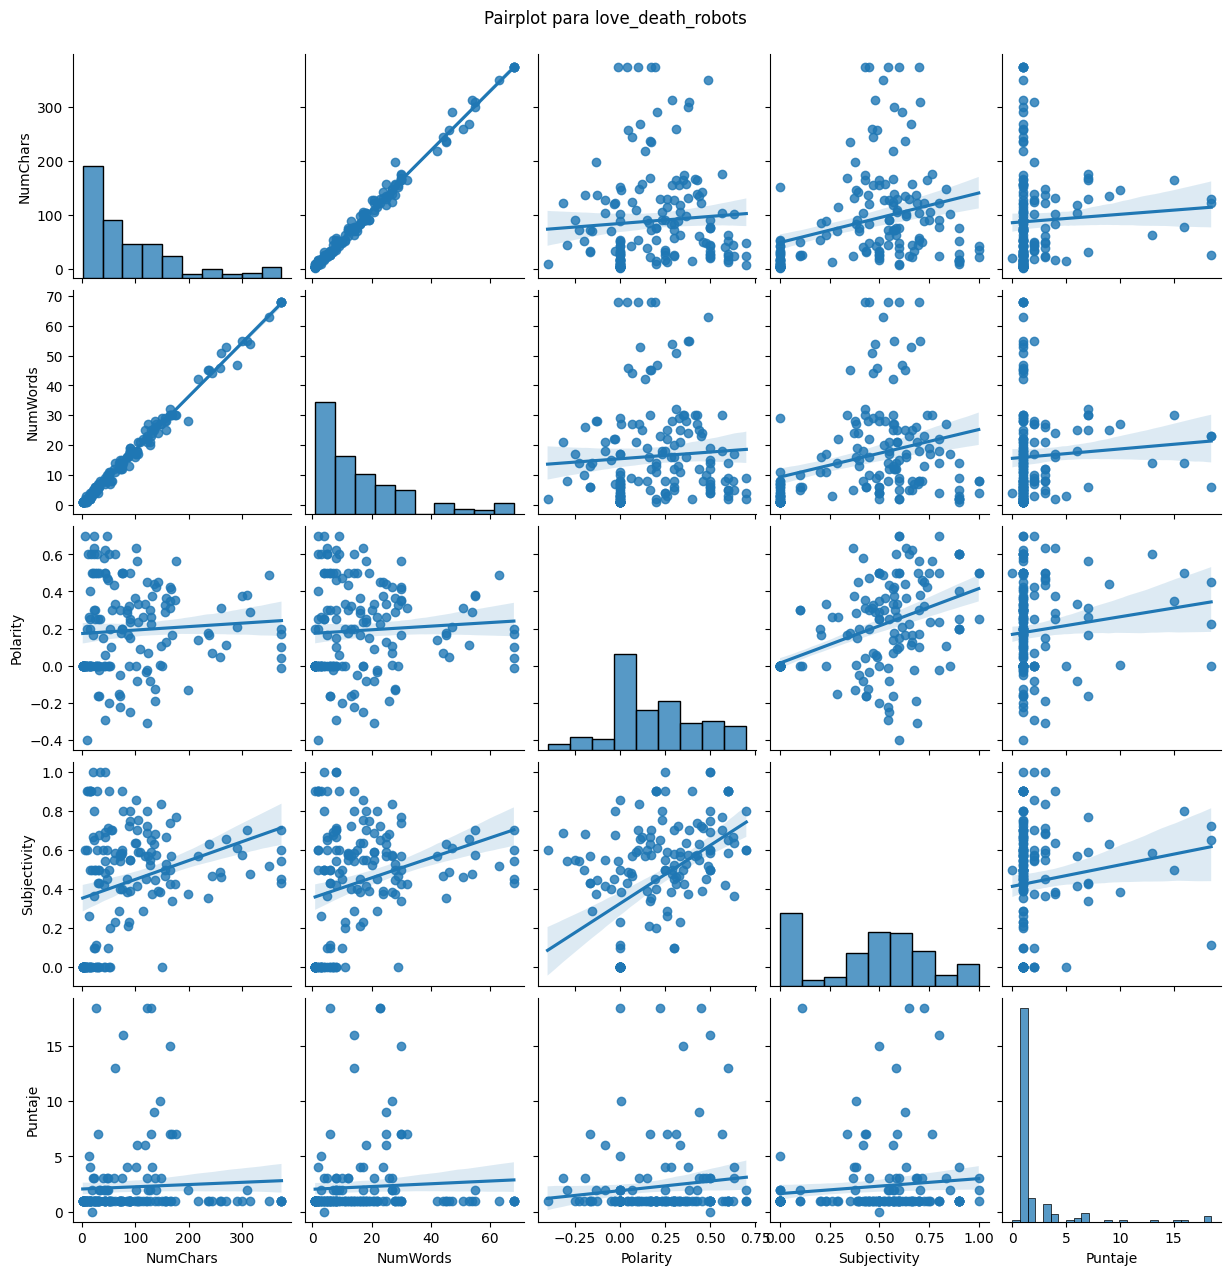

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

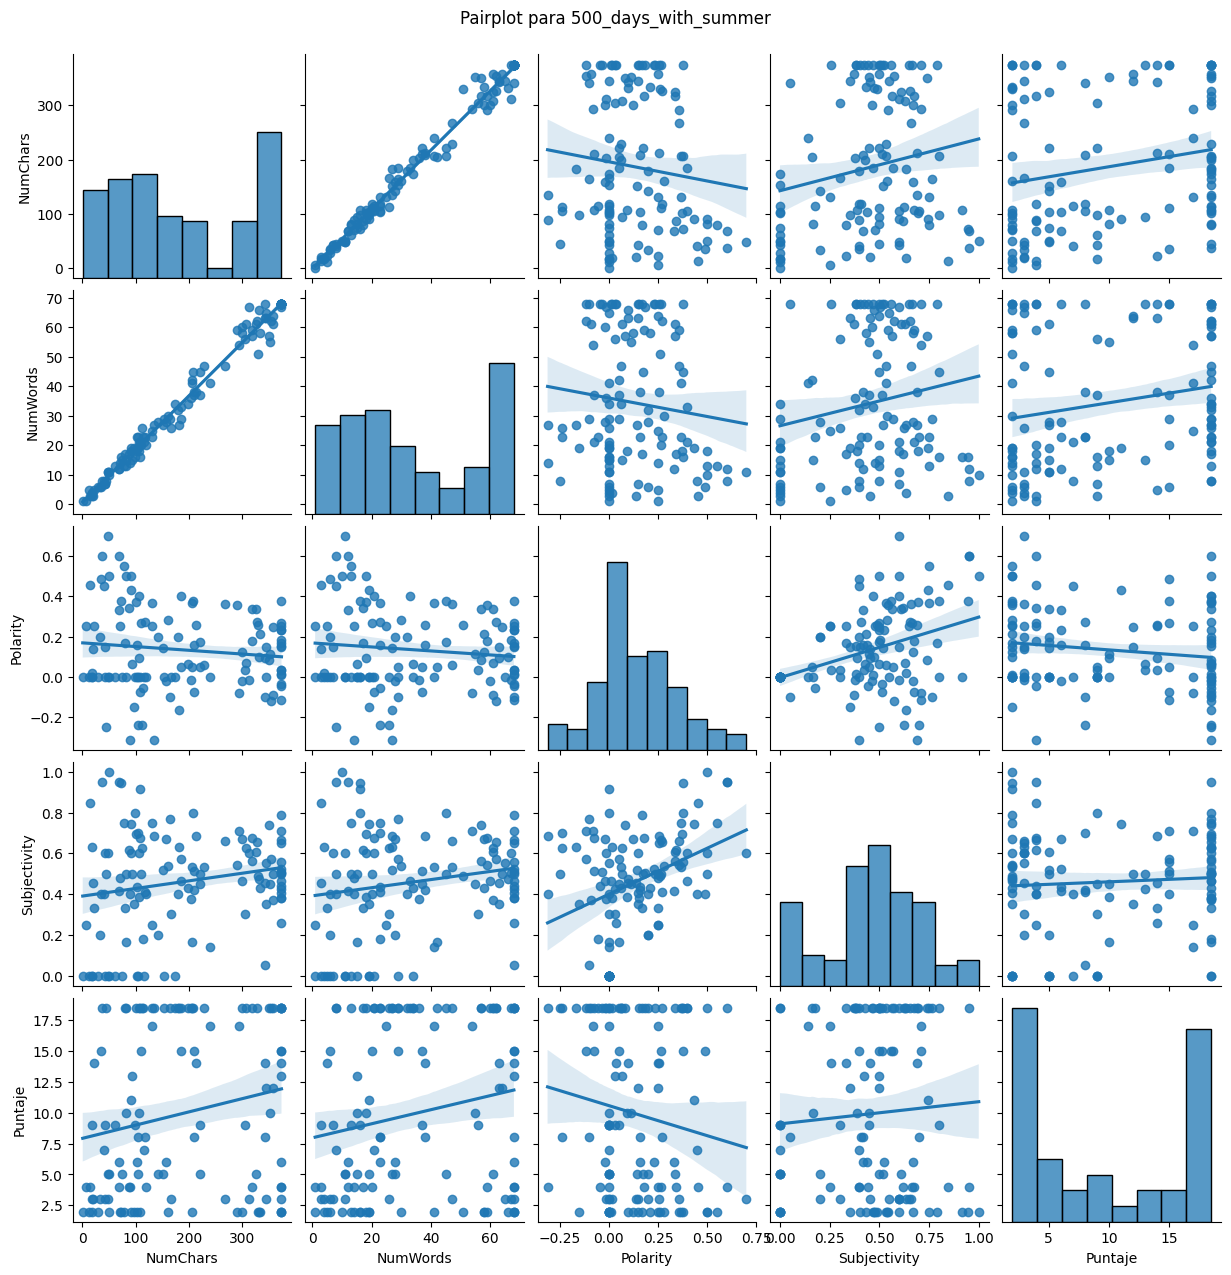

c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\aaram\Documents\5to semestre\DIplomado datos\Poster\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarni

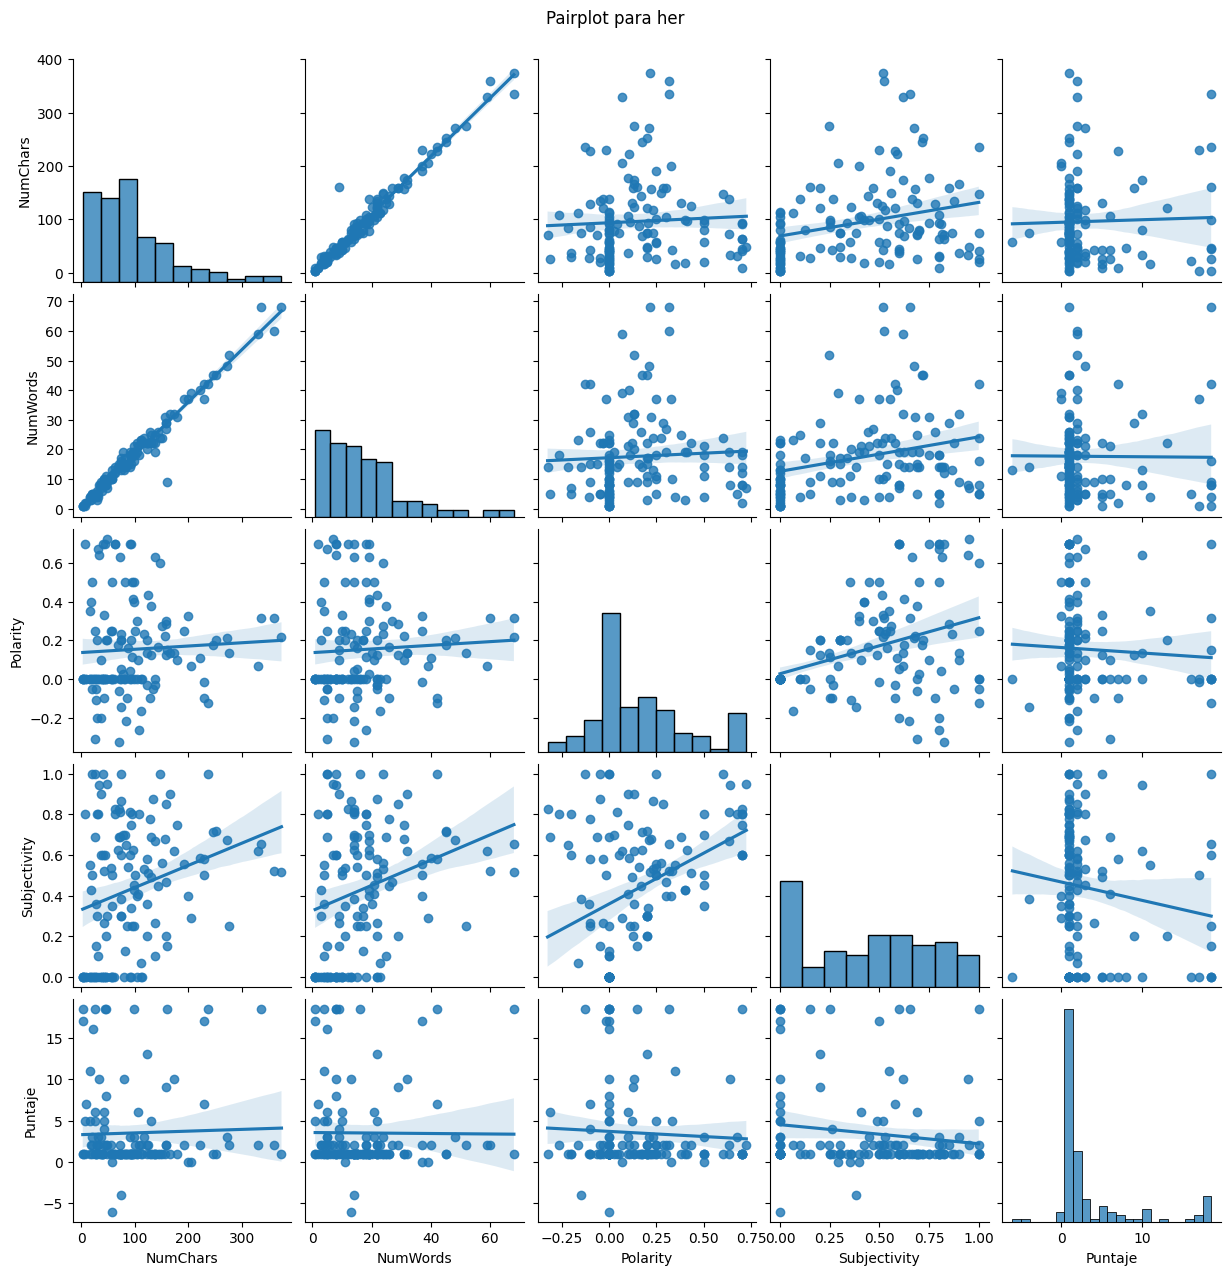

In [24]:
for movie in df_sin_outliers['Movie'].unique():
    sns.pairplot(
        df_sin_outliers[df_sin_outliers['Movie'] == movie],
        vars=columnas_numericas,
        kind="reg",
        palette="husl"
    )
    plt.suptitle(f"Pairplot para {movie}", y=1.02)
    plt.show()

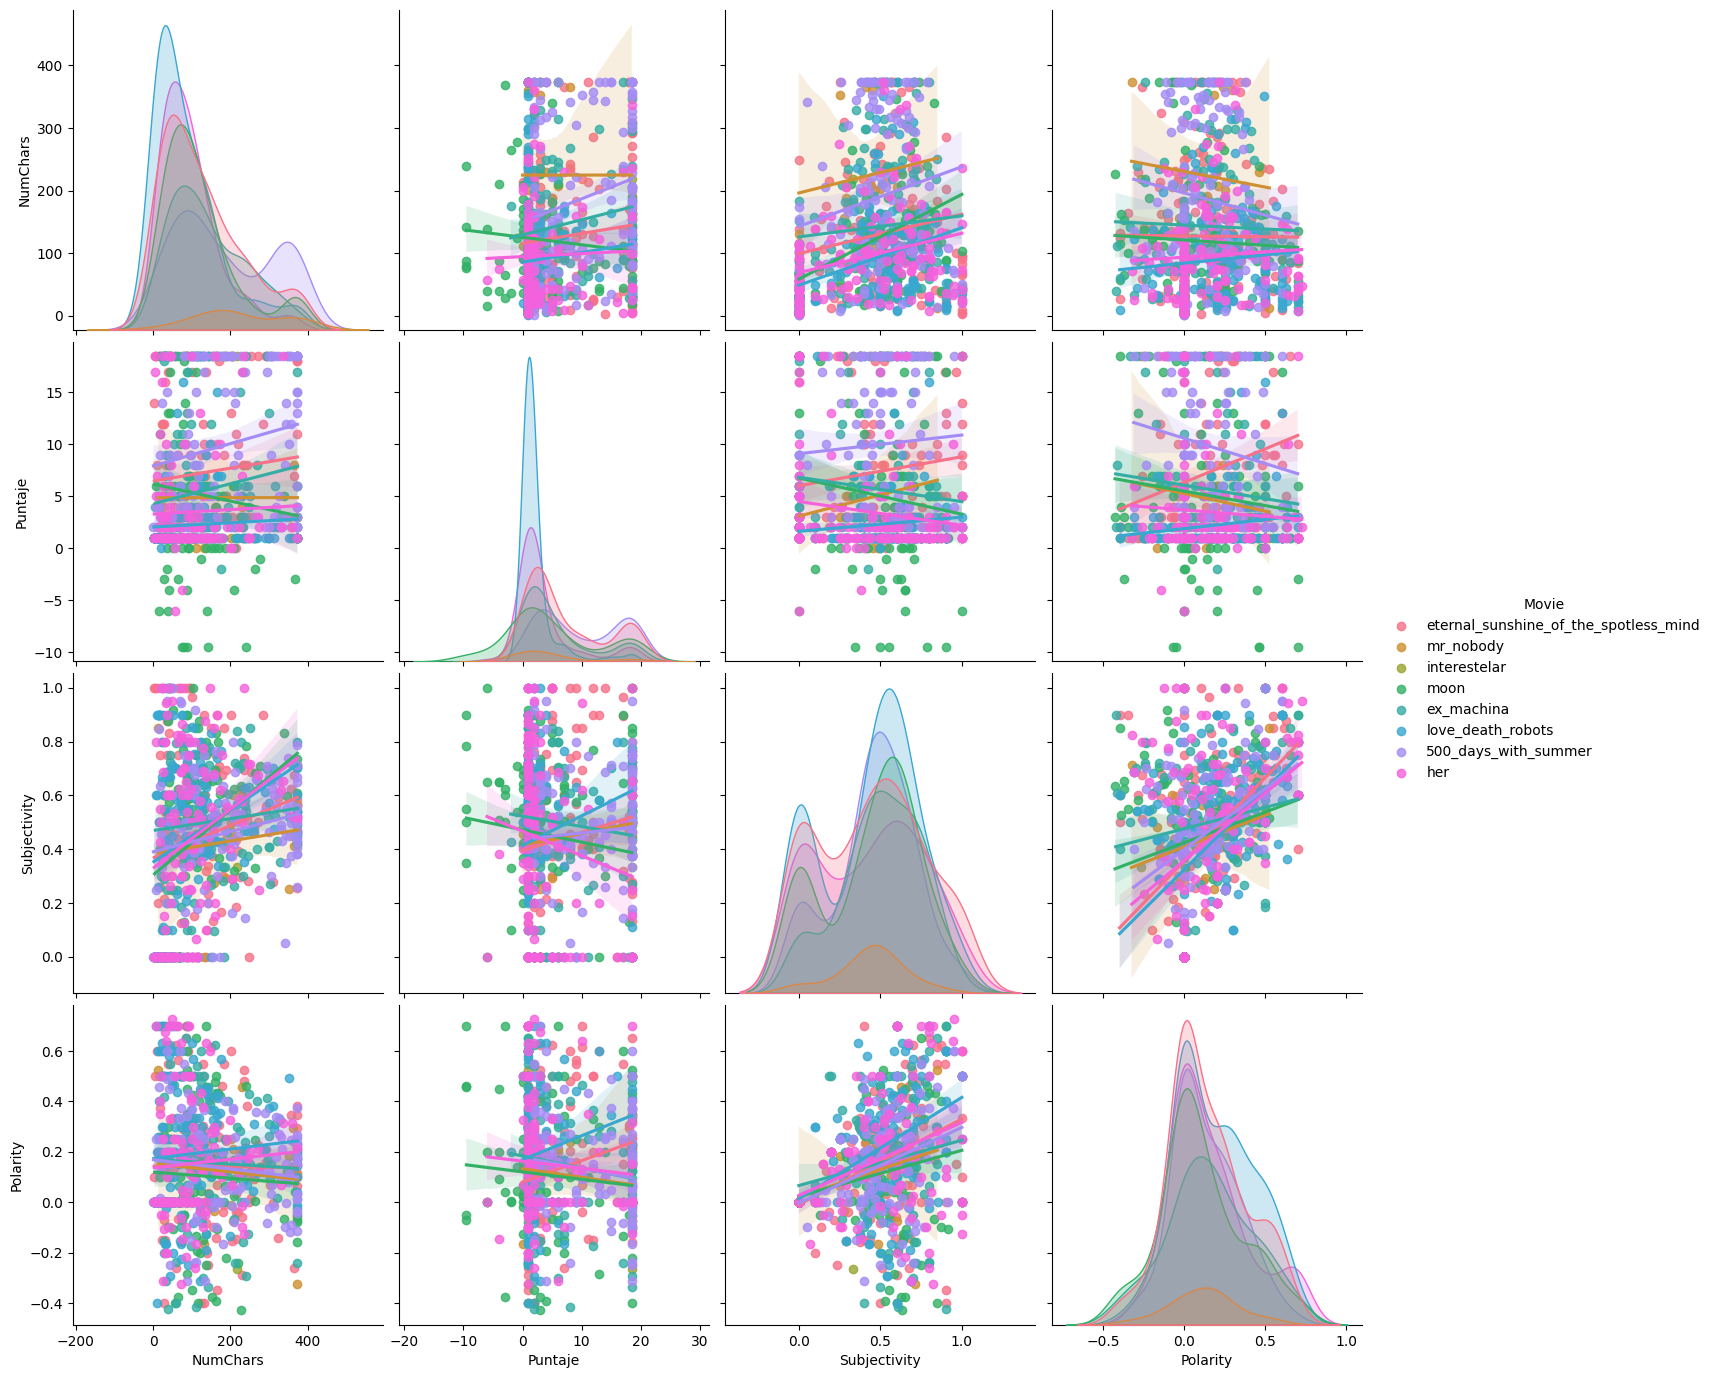

In [25]:
sns.pairplot(
    df_sin_outliers,
    vars=['NumChars', 'Puntaje', 'Subjectivity', 'Polarity'],
    kind="reg",
    hue="Movie",
    palette="husl",
    height=3.5  # Puedes aumentar este valor para hacerlo aún más grande
)
plt.show()


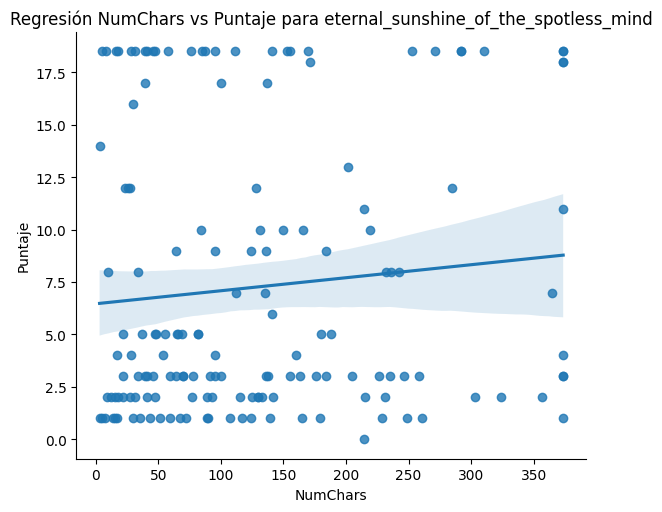

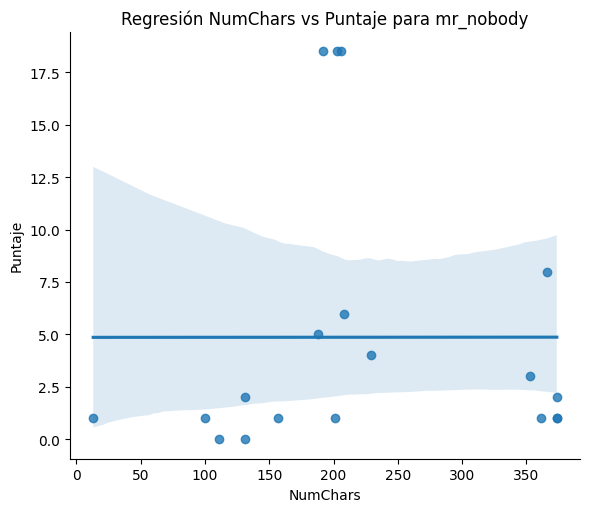

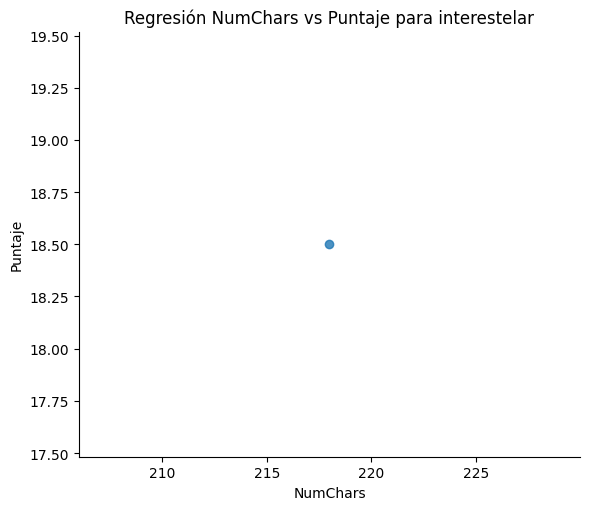

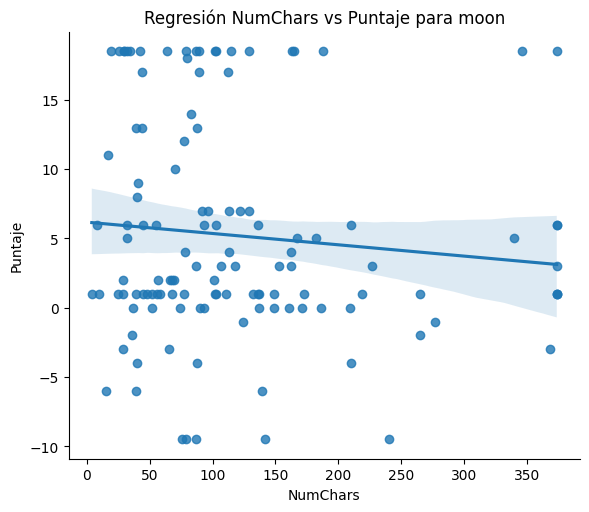

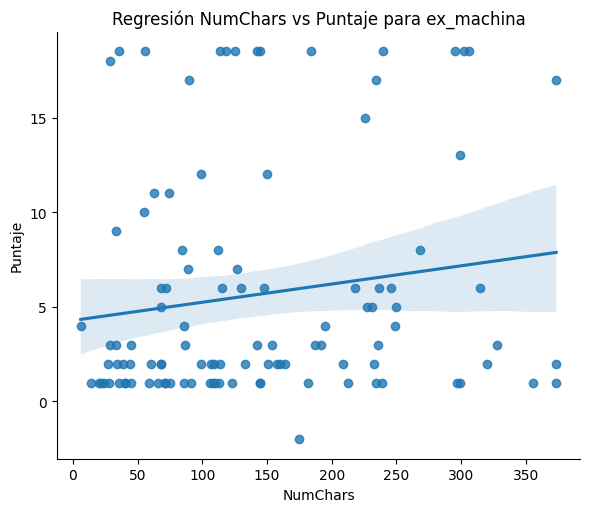

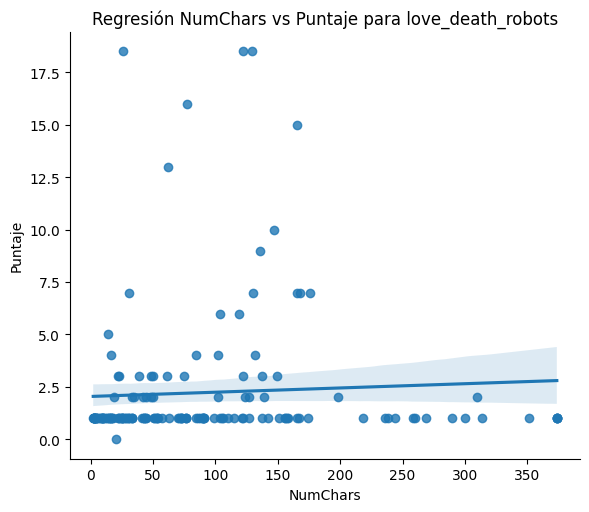

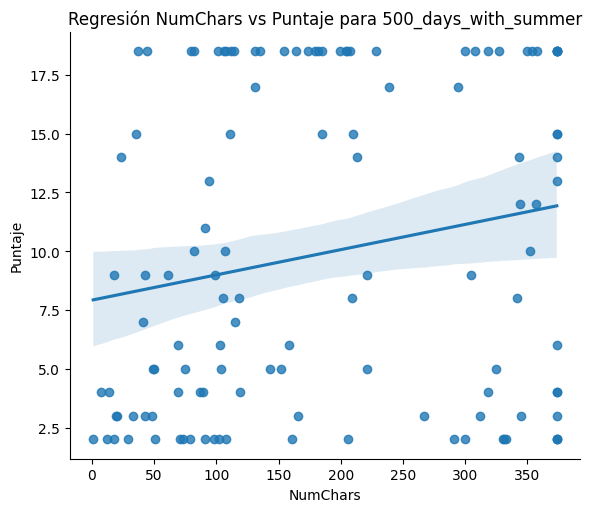

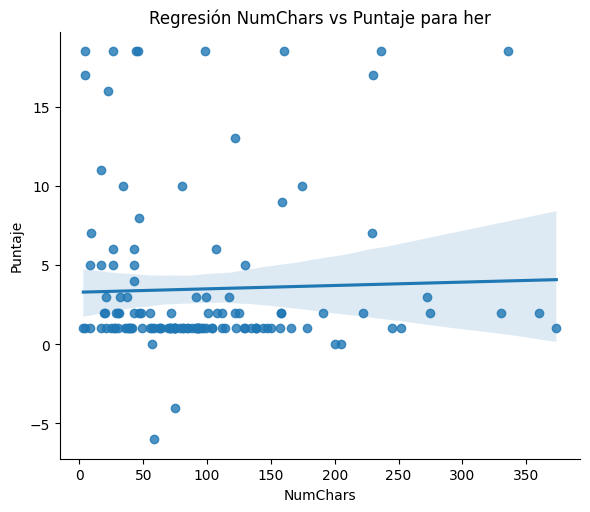

In [26]:
for movie in df_sin_outliers['Movie'].unique():
    sns.lmplot(
        x="NumChars",
        y="Puntaje",
        data=df_sin_outliers[df_sin_outliers['Movie'] == movie],
        height=5,
        aspect=1.2
    )
    plt.title(f'Regresión NumChars vs Puntaje para {movie}')
    plt.show()

Kmeans 

¿Qué es StandardScaler? Una técnica de preprocesamiento para estandarizar características.

Transforma las variables para que tengan:

Media = 0
Desviación estándar = 1
Fórmula (para cada característica x):  z=(x−μ)/σ 
Donde:

𝜇: media de la característica

𝜎: desviación estándar

¿Por qué es importante?

Ayuda a K-Means a tratar todas las características por igual eliminando el sesgo de escala.

Es especialmente útil cuando las variables tienen distintas unidades o escalas.

In [38]:
#Scaling Data

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)
X_escalado

array([[-1.1243985 , -1.11406975, -0.19572367,  1.90275876,  0.52081817],
       [-0.823541  , -0.91832643,  1.98490485,  1.46899406, -0.20072279],
       [ 0.29140148,  0.54974847, -1.19950505,  0.79424898, -0.36106523],
       ...,
       [-1.071306  , -1.06513392, -0.61108148, -1.56735881, -0.04038036],
       [-0.27491851, -0.13535315,  1.46570759, -0.0058059 , -0.36106523],
       [-0.965121  , -0.91832643, -0.61108148, -1.56735881, -0.36106523]],
      shape=(816, 5))

CLusterizacion

Es una técnica para encontrar el número óptimo de clústeres (K) en K-Means.

Usa la métrica llamada inercia:

Inercia=∑i=1n||xi−ck||2 

Donde:

xi  = punto de datos

ck  = centroide del clúster más cercano

Pasos:

Graficar inercia vs. número de clústeres (K).

Identificar el punto donde:

La inercia deja de disminuir bruscamente.

Agregar más clústeres ya no mejora significativamente el modelo.


Elbow method (Método del codo)

In [39]:
#Creating values for the elbow
inertia = []
k = range(1,20)
for i in k:
    means_k = KMeans(n_clusters = i, init = 'k-means++', random_state=0, n_init = 10)
    means_k.fit(X_escalado)
    inertia.append(means_k.inertia_)

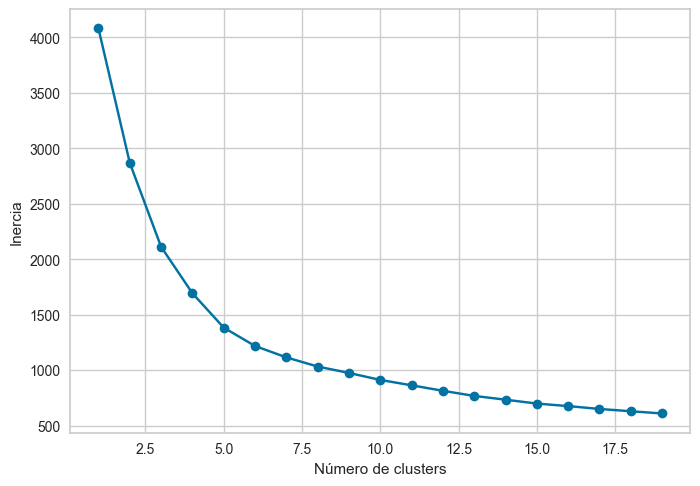

In [40]:
#Plotting the elbow
plt.plot(k , inertia , 'bo-')
plt.xlabel('Número de clusters') , plt.ylabel('Inercia')
plt.show()

In [41]:
!pip install yellowbrick


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\aaram\Documents\5to semestre\DIplomado datos\Actividad 3\.venv\Scripts\python.exe -m pip install --upgrade pip


In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Carga de datos (ajusta la ruta si es necesario)
df = pd.read_csv('Comentarios_Clusterizados_EDA_ok.csv')

# 2. Selección de variables para clusterizar
features = ['NumChars', 'NumWords', 'Polarity', 'Subjectivity', 'Puntaje']
X = df[features].values

# 3. Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. K-Means con 6 clusters y semilla fija
kmeans = KMeans(
    n_clusters=6,
    init='k-means++',
    n_init=10,          # número de inicializaciones
    random_state=42     # semilla para reproducibilidad
)
labels = kmeans.fit_predict(X_scaled)

# 5. Añadir la columna de cluster al DataFrame
df['cluster'] = labels

# 6. Obtener centroides en escala original
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
df_centroids = pd.DataFrame(centroids, columns=features)
df_centroids.index.name = 'cluster'

# 7. Resultado: conteo por cluster y tabla de centroides
print("Número de comentarios por cluster:")
print(df['cluster'].value_counts().sort_index(), "\n")

print("Centroides (en la escala original):")
print(df_centroids)


Número de comentarios por cluster:
cluster
0    136
1     93
2    176
3    156
4     59
5    196
Name: count, dtype: int64 

Centroides (en la escala original):
           NumChars   NumWords  Polarity  Subjectivity    Puntaje
cluster                                                          
0         85.036765  15.529412 -0.092586      0.641507   3.367647
1        374.161290  67.365591  0.128198      0.538565   8.451613
2         75.613636  13.863636  0.472598      0.675305   4.267045
3        181.711538  33.391026  0.168747      0.475178   4.653846
4        154.254237  28.474576  0.107892      0.457378  43.423729
5         46.010204   8.607143  0.024761      0.057485   4.285714


In [35]:
from yellowbrick.cluster import KElbowVisualizer

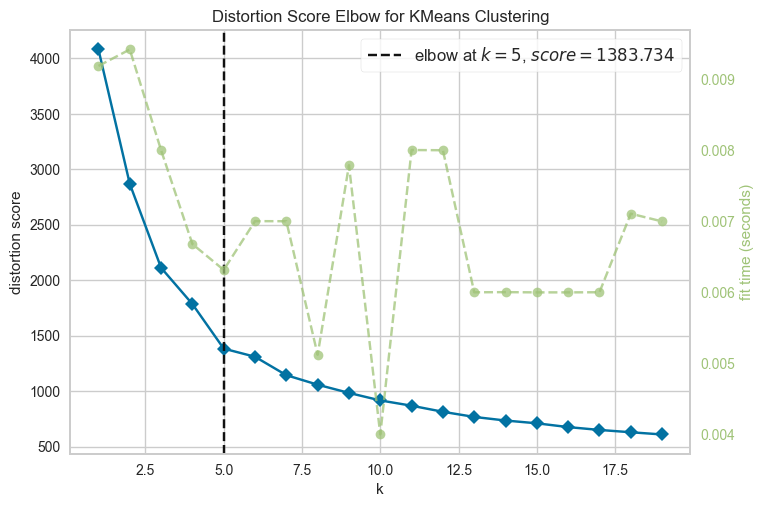

In [43]:
model = KMeans(init = 'k-means++', random_state=0)

visualizer = KElbowVisualizer(model, k=(1,20), init = 'k-means++', n_init = 10)

visualizer.fit(X_escalado)
visualizer.show()
plt.show()

In [47]:
# Obtener los centroides del modelo means_k y crear un DataFrame con los nombres de columnas deseados
columnas = ['NumChars', 'NumWords', 'Polarity', 'Subjectivity', 'Puntaje']
centroids_df = pd.DataFrame(means_k.cluster_centers_, columns=columnas)
print(centroids_df)

    NumChars  NumWords  Polarity  Subjectivity   Puntaje
0   0.097183  0.098033 -1.447272      0.710308 -0.229502
1  -0.949125 -0.942324 -0.587974     -1.523089 -0.391900
2  -0.629606 -0.628789  1.638120      0.286876 -0.367746
3   1.685778  1.634063 -0.312089      0.474324  1.208603
4   0.072905  0.082976 -0.177054     -0.072327  4.134690
5  -0.488635 -0.493329  0.181289     -0.179704 -0.239066
6   0.575722  0.574618 -0.351911     -0.222727 -0.240151
7   0.078329  0.084470  0.948464      0.562945 -0.377608
8  -0.610223 -0.640441 -0.542954     -1.393451  1.860823
9   1.733532  1.708692  0.160799      0.259795 -0.327824
10  2.691182  2.687545 -0.241886      0.262967 -0.173236
11 -0.661003 -0.660769 -1.510707      0.246879 -0.591030
12 -0.368715 -0.368288  1.129920      0.907676  1.649629
13 -0.633824 -0.643307 -0.238298      1.269366 -0.412375
14 -0.314207 -0.302714 -0.633234     -1.436940 -0.377099
15  0.281621  0.307645 -0.998189      0.423099  1.816216
16 -0.625214 -0.627903  1.83057

Indice de silueta
Mide qué tan bien se ajusta un punto a su clúster.

Fórmula:

s=(b−a)/max(a,b) 

Donde:

a  = distancia promedio a los puntos del mismo clúster

b  = distancia promedio al clúster más cercano

Interpretación:

Cercano a 1 → Buen agrupamiento (compacto y bien separado).

Cerca de 0 → Puntos solapados o en el borde entre clústeres.

Negativo → Punto mal asignado (debería estar en otro clúster).

In [49]:
from sklearn.metrics import silhouette_score

X = df_sin_outliers[columnas_numericas]
X_escalado = scaler.fit_transform(X)

kmeans_6 = KMeans(n_clusters=6, init='k-means++', random_state=0, n_init=10)
kmeans_6.fit(X_escalado)
silhouette_6 = silhouette_score(X_escalado, kmeans_6.labels_)

print(f"Índice de Silueta para 6 clústeres: {silhouette_6:.4f}")

Índice de Silueta para 6 clústeres: 0.3284


In [51]:
# Entrenamiento de KMeans con 3 clústeres para los datos sin outliers
means_k = KMeans(n_clusters=6, init='k-means++', random_state=0, n_init=10)
means_k.fit(X_escalado)
labels = means_k.labels_
print(labels)

centroids = means_k.cluster_centers_

df_sin_outliers['clusters'] = labels

labels_unique = df_sin_outliers['clusters'].unique()
centroides = means_k.cluster_centers_

print(labels_unique)

[4 1 3 1 1 2 4 0 1 5 1 3 1 3 5 4 1 4 1 0 0 1 3 1 0 0 3 0 2 1 0 3 4 2 4 5 3
 3 4 4 0 0 4 4 1 3 0 2 0 4 2 4 3 4 4 2 0 5 3 4 2 3 4 4 1 4 2 4 4 4 1 4 4 1
 3 1 0 3 3 2 1 2 1 5 1 2 2 0 1 0 0 3 1 1 0 5 5 1 2 4 0 3 5 1 0 4 0 1 1 0 0
 5 3 3 0 5 0 0 0 0 5 5 3 5 5 5 5 0 3 0 0 1 5 5 0 0 3 1 1 1 5 3 3 5 0 0 0 0
 1 5 3 5 5 0 3 4 1 5 2 2 5 3 3 0 5 3 5 5 0 5 3 5 5 5 2 4 5 2 4 4 3 4 4 0 0
 1 4 5 4 3 4 0 0 3 4 1 4 0 1 3 3 1 3 5 1 1 1 3 0 4 4 0 4 4 4 2 0 4 3 0 5 1
 5 4 4 3 4 3 3 3 4 0 2 5 1 1 4 1 4 4 5 3 4 0 3 1 3 3 3 5 1 3 1 3 3 3 3 3 3
 3 4 3 0 1 0 1 5 3 3 5 5 5 0 1 1 0 1 1 0 0 3 1 0 5 1 3 0 3 5 3 5 1 5 3 0 3
 0 4 4 5 3 5 2 3 1 3 4 3 0 1 1 5 0 3 1 4 4 4 3 0 5 5 5 4 1 4 1 0 4 4 2 5 5
 1 2 2 3 3 5 3 5 5 5 0 5 3 0 0 2 0 4 2 2 0 3 1 4 3 3 5 3 5 3 1 1 3 1 3 5 5
 3 1 1 5 3 3 3 1 5 0 0 5 2 5 1 3 3 1 3 3 1 1 5 1 1 0 0 1 3 3 1 5 5 3 3 4 1
 4 0 1 0 1 3 4 1 3 1 3 3 1 4 1 3 1 1 1 1 3 4 1 1 1 1 1 1 5 1 1 1 3 3 0 0 3
 3 1 0 3 3 5 3 5 0 0 0 0 0 0 0 5 3 0 0 1 0 0 0 3 1 1 1 1 0 0 0 3 5 1 1 0 0
 5 0 0 0 0 1 3 1 1 0 0 3 

In [52]:
# prompt: desescalar los centroides del modelo

# Desescalar (inverse_transform) los centros
centroides_desescalados = scaler.inverse_transform(centroides)

print("Centroides desescalados:")
centroides_desescalados


Centroides desescalados:


array([[ 4.81647727e+01,  9.15340909e+00,  2.66473788e-02,
         5.61215237e-02,  2.31818182e+00],
       [ 8.36149733e+01,  1.53903743e+01,  4.64571942e-01,
         6.66404077e-01,  3.47326203e+00],
       [ 3.01551724e+02,  5.48103448e+01,  7.96040948e-02,
         5.15458967e-01,  1.68017241e+01],
       [ 9.87000000e+01,  1.79647059e+01, -3.16140636e-02,
         5.93302901e-01,  2.32941176e+00],
       [ 9.18019802e+01,  1.64455446e+01,  1.10975124e-01,
         3.75760993e-01,  1.70990099e+01],
       [ 2.88858871e+02,  5.28548387e+01,  1.45445820e-01,
         5.27099490e-01,  2.64919355e+00]])

In [53]:
df_sin_outliers.head()

,Movie,URL,Fecha UTC,Autor,Comentario,Puntaje,Nivel,NumChars,NumWords,Polarity,Subjectivity,Cluster,clusters
0,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-08-09 02:42:55,RealNoodles221,wow,14.0,3,3.0,1,0.100000,1.000000,4,4
1,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-11-19 09:33:38,Zestyclose-Sir-851,Agreed! Lovely and astounding ending!,5.0,2,37.0,5,0.625000,0.875000,4,1
2,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-11-20 01:23:04,Confident-City-3108,"Yes! It hit me too, look on te other side of a...",3.0,2,163.0,35,-0.141667,0.680556,4,3
3,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2025-03-14 13:56:34,ilovetyrol,"Yes. That final ""okay."" Best ending to a won...",3.0,2,59.0,10,0.625000,0.700000,4,1
4,eternal_sunshine_of_the_spotless_mind,https://www.reddit.com/r/movies/comments/195s5...,2024-01-13 17:01:53,[deleted],Yeah. The scene where he can’t accept his deci...,18.5,2,95.0,18,0.500000,1.000000,4,1


In [54]:
print('Polarity')
display(df_sin_outliers.groupby('clusters').Polarity.describe().T)

print('Subjectivity')
display(df_sin_outliers.groupby('clusters').Subjectivity.describe().T)

print('Puntaje')
display(df_sin_outliers.groupby('clusters').Puntaje.describe().T)

Polarity


clusters,0,1,2,3,4,5
count,176.000000,187.000000,58.000000,170.000000,101.000000,124.000000
mean,0.026647,0.464572,0.079604,-0.031614,0.110975,0.145446
std,0.086965,0.145321,0.168645,0.178259,0.208381,0.168355
min,-0.200000,0.200000,-0.291667,-0.428571,-0.400000,-0.326667
25%,0.000000,0.333333,-0.032509,-0.154688,0.000000,0.037917
50%,0.000000,0.500000,0.074226,0.000000,0.065000,0.163036
75%,0.000000,0.600000,0.210833,0.125000,0.250000,0.250000
max,0.333333,0.725000,0.412000,0.250000,0.525000,0.522727


Subjectivity


clusters,0,1,2,3,4,5
count,176.000000,187.000000,58.000000,170.000000,101.000000,124.000000
mean,0.056122,0.666404,0.515459,0.593303,0.375761,0.527099
std,0.100915,0.191740,0.170601,0.178315,0.283821,0.155208
min,0.000000,0.183333,0.142857,0.266667,0.000000,0.000000
25%,0.000000,0.500000,0.408962,0.450000,0.112500,0.440804
50%,0.000000,0.630000,0.501736,0.589583,0.400000,0.529750
75%,0.100000,0.806481,0.621094,0.687500,0.600000,0.628929
max,0.383333,1.000000,1.000000,1.000000,1.000000,0.850000


Puntaje


clusters,0,1,2,3,4,5
count,176.000000,187.000000,58.000000,170.000000,101.000000,124.000000
mean,2.318182,3.473262,16.801724,2.329412,17.099010,2.649194
std,2.414459,4.478063,2.643993,3.048962,2.525886,2.671728
min,-6.000000,-9.500000,10.000000,-9.500000,9.000000,-9.500000
25%,1.000000,1.000000,15.000000,1.000000,17.000000,1.000000
50%,1.000000,2.000000,18.500000,2.000000,18.500000,2.000000
75%,3.000000,5.000000,18.500000,3.000000,18.500000,4.000000
max,11.000000,18.500000,18.500000,12.000000,18.500000,9.000000


In [55]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\aaram\Documents\5to semestre\DIplomado datos\Actividad 3\.venv\Scripts\python.exe -m pip install --upgrade pip


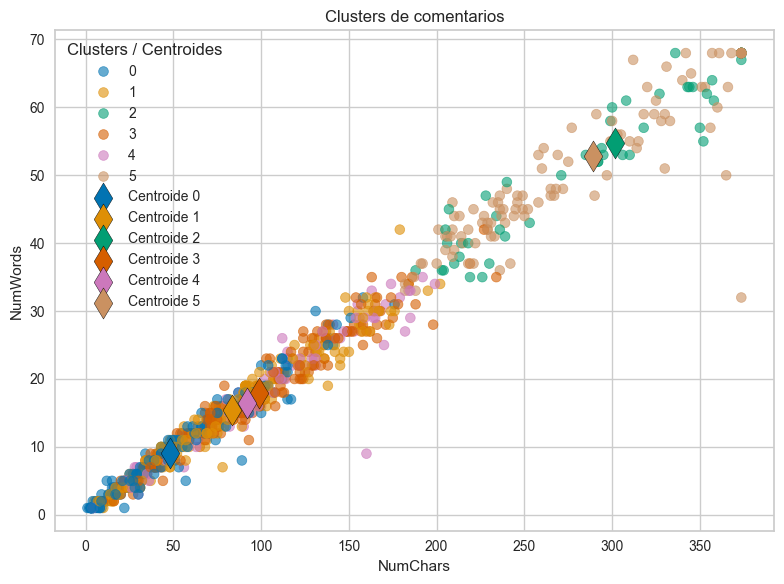

In [56]:
# Gráfico de dispersión de los datos escalados con colores por clúster
plt.figure(figsize=(8, 6))
palette = sns.color_palette("colorblind", n_colors=len(df_sin_outliers['clusters'].unique()))
scatter = sns.scatterplot(
    x=df_sin_outliers['NumChars'],
    y=df_sin_outliers['NumWords'],
    hue=df_sin_outliers['clusters'],
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    legend='full'
)
plt.title('Clusters de comentarios')
plt.xlabel('NumChars')
plt.ylabel('NumWords')

# Dibujar los centroides desescalados en el mismo espacio
for idx, (x, y) in enumerate(centroides_desescalados[:, :2]):
    plt.scatter(
        x, y,
        marker='d',
        c=[palette[idx]],
        s=250,
        edgecolors='black',
        label=f'Centroide {idx}'
    )

# Evitar duplicados en la leyenda
handles, labels_ = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
plt.legend(by_label.values(), by_label.keys(), title="Clusters / Centroides")
plt.tight_layout()
plt.show()


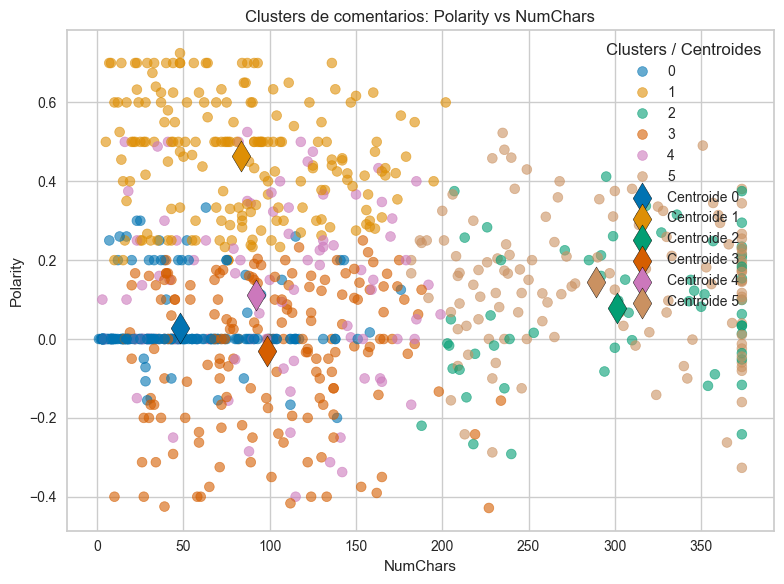

In [57]:
# Gráfico de dispersión de Polarity vs NumChars, coloreado por clúster
plt.figure(figsize=(8, 6))
palette = sns.color_palette("colorblind", n_colors=len(df_sin_outliers['clusters'].unique()))
scatter = sns.scatterplot(
    x=df_sin_outliers['NumChars'],
    y=df_sin_outliers['Polarity'],
    hue=df_sin_outliers['clusters'],
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    legend='full'
)
plt.title('Clusters de comentarios: Polarity vs NumChars')
plt.xlabel('NumChars')
plt.ylabel('Polarity')

# Dibujar los centroides desescalados en el mismo espacio
for idx, (x, y) in enumerate(centroides_desescalados[:, [0, 2]]):
    plt.scatter(
        x, y,
        marker='d',
        c=[palette[idx]],
        s=250,
        edgecolors='black',
        label=f'Centroide {idx}'
    )

# Evitar duplicados en la leyenda
handles, labels_ = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
plt.legend(by_label.values(), by_label.keys(), title="Clusters / Centroides")
plt.tight_layout()
plt.show()

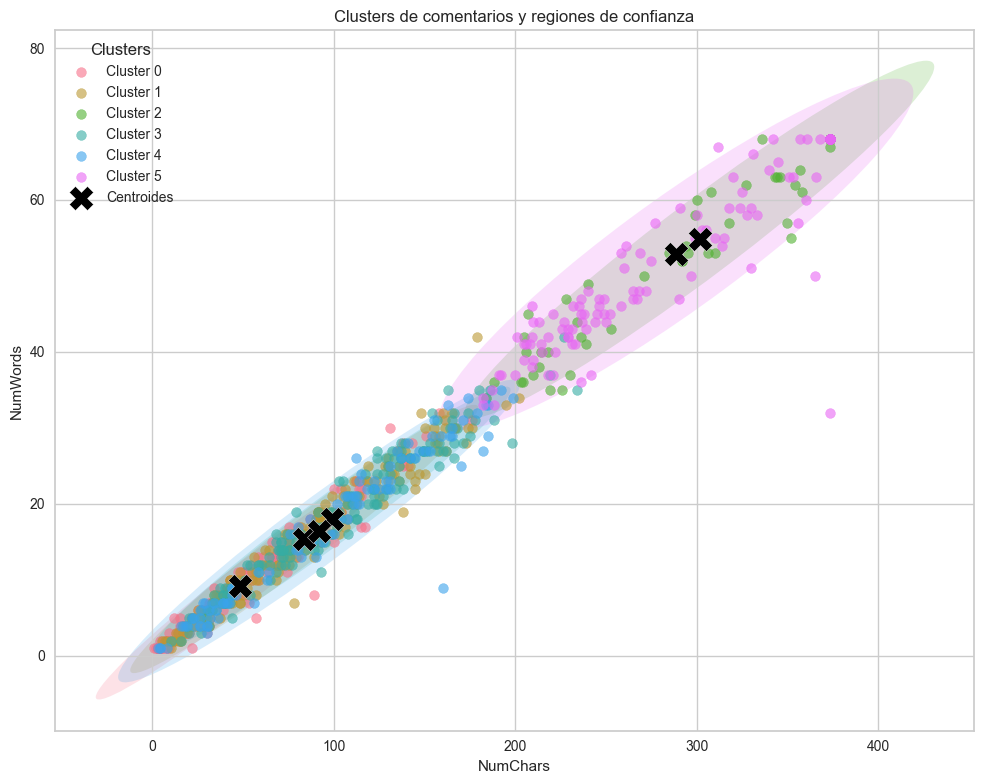

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# Función para dibujar la elipse de confianza
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# Selecciona dos variables numéricas para graficar
features_for_plot = ["NumChars", "NumWords"]
X_plot = df_sin_outliers[features_for_plot].values

labels = df_sin_outliers['clusters']
unique_labels = np.unique(labels)
n_clusters = len(unique_labels)
colors = sns.color_palette("husl", n_clusters)

plt.figure(figsize=(10, 8))
ax = plt.gca()

for i, label in enumerate(unique_labels):
    cluster_data = df_sin_outliers[df_sin_outliers['clusters'] == label]
    ax.scatter(cluster_data[features_for_plot[0]], cluster_data[features_for_plot[1]],
               color=colors[i], label=f'Cluster {label}', alpha=0.6, s=50)
    if len(cluster_data) > 1:
        confidence_ellipse(cluster_data[features_for_plot[0]].values,
                           cluster_data[features_for_plot[1]].values,
                           ax, n_std=2.0, facecolor=colors[i], alpha=0.2, zorder=0)

# Centroides desescalados
ax.scatter(centroides_desescalados[:, features_for_plot.index("NumChars")],
           centroides_desescalados[:, features_for_plot.index("NumWords")],
           marker='X', s=300, c='black', edgecolors='white', label='Centroides')

plt.xlabel(features_for_plot[0])
plt.ylabel(features_for_plot[1])
plt.title('Clusters de comentarios y regiones de confianza')
plt.legend(title='Clusters')
plt.grid(True)
plt.tight_layout()
plt.show()

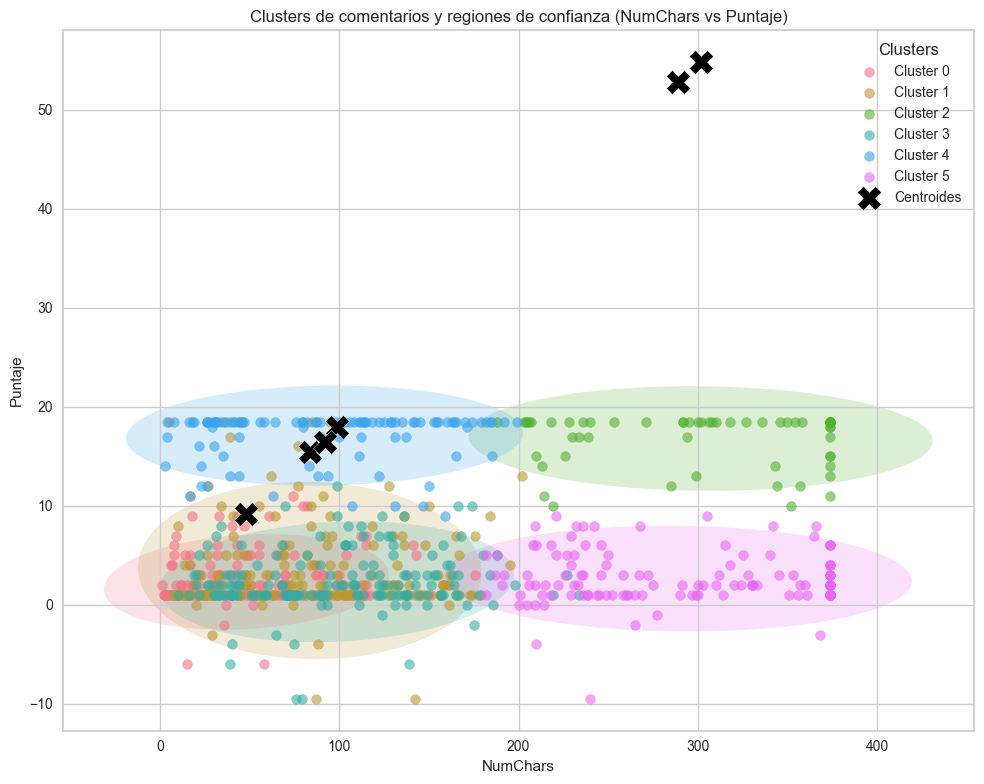

In [63]:
# Cambia las variables a 'NumChars' y 'Puntaje'
features_for_plot = ["NumChars", "Puntaje"]
X_plot = df_sin_outliers[features_for_plot].values

labels = df_sin_outliers['clusters']
unique_labels = np.unique(labels)
n_clusters = len(unique_labels)
colors = sns.color_palette("husl", n_clusters)

plt.figure(figsize=(10, 8))
ax = plt.gca()

for i, label in enumerate(unique_labels):
    cluster_data = df_sin_outliers[df_sin_outliers['clusters'] == label]
    ax.scatter(cluster_data[features_for_plot[0]], cluster_data[features_for_plot[1]],
               color=colors[i], label=f'Cluster {label}', alpha=0.6, s=50)
    if len(cluster_data) > 1:
        confidence_ellipse(cluster_data[features_for_plot[0]].values,
                           cluster_data[features_for_plot[1]].values,
                           ax, n_std=2.0, facecolor=colors[i], alpha=0.2, zorder=0)

# Centroides desescalados
ax.scatter(
    centroides_desescalados[:, features_for_plot.index("NumChars")],
    centroides_desescalados[:, features_for_plot.index("Puntaje")],
    marker='X', s=300, c='black', edgecolors='white', label='Centroides'
)

plt.xlabel(features_for_plot[0])
plt.ylabel(features_for_plot[1])
plt.title('Clusters de comentarios y regiones de confianza (NumChars vs Puntaje)')
plt.legend(title='Clusters')
plt.grid(True)
plt.tight_layout()
plt.show()

clusters,0,1,2,3,4,5
Movie,,,,,,
500_days_with_summer,0.038235,0.442556,0.091894,-0.009157,0.113906,0.157508
eternal_sunshine_of_the_spotless_mind,0.023340,0.471005,0.115539,-0.035139,0.129993,0.114412
ex_machina,0.029060,0.512359,0.108816,-0.030668,0.147708,0.143354
her,0.015085,0.482432,0.057906,0.003123,0.052778,0.163981
interestelar,0.000000,0.000000,-0.266667,0.000000,0.000000,0.000000
love_death_robots,0.035325,0.429212,0.000000,-0.043099,0.205333,0.191359
moon,0.026190,0.489301,-0.049797,-0.065720,0.072530,0.097287
mr_nobody,0.000000,0.525000,-0.043095,0.015341,0.137500,0.173684


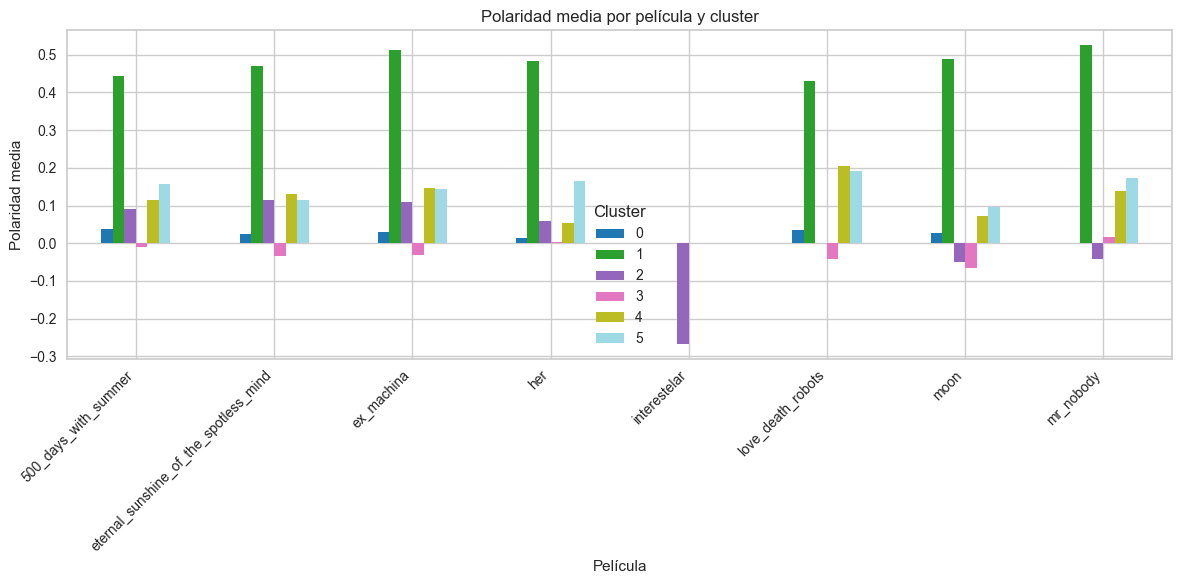

In [65]:
# Agrupar por película y cluster, calculando la polaridad media de cada grupo
polaridad_por_pelicula_cluster = df_sin_outliers.groupby(['Movie', 'clusters'])['Polarity'].mean().unstack(fill_value=0)

# Mostrar la tabla resultante
display(polaridad_por_pelicula_cluster)

# Graficar la polaridad media por película y cluster
polaridad_por_pelicula_cluster.plot(kind='bar', figsize=(12, 6), colormap='tab20')
plt.title('Polaridad media por película y cluster')
plt.xlabel('Película')
plt.ylabel('Polaridad media')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [66]:
!pip install plotly


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\aaram\Documents\5to semestre\DIplomado datos\Actividad 3\.venv\Scripts\python.exe -m pip install --upgrade pip


In [67]:
!pip install nbformat --upgrade


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\aaram\Documents\5to semestre\DIplomado datos\Actividad 3\.venv\Scripts\python.exe -m pip install --upgrade pip


In [68]:
import plotly as py

import plotly.graph_objs as go

# Usamos las columnas numéricas del clustering real: 'NumChars', 'NumWords', 'Puntaje'
labels = means_k.labels_

trace1 = go.Scatter3d(
    x=df_sin_outliers['NumChars'],
    y=df_sin_outliers['NumWords'],
    z=df_sin_outliers['Puntaje'],
    mode='markers',
    marker=dict(
        color=labels,
        size=7,
        opacity=0.8,
        line=dict(width=0)
    )
)

layout = go.Layout(
    title='Clusters (KMeans) en 3D',
    scene=dict(
        xaxis=dict(title='NumChars'),
        yaxis=dict(title='NumWords'),
        zaxis=dict(title='Puntaje')
    )
)

fig = go.Figure(data=[trace1], layout=layout)
py.offline.iplot(fig)

In [70]:
# Define los nombres de las columnas si no están definidos
cluster_col = 'clusters'  # o 'Cluster' según el DataFrame que uses
text_col = 'Comentario'
metrics = columnas_numericas  # ['NumChars', 'NumWords', 'Polarity', 'Subjectivity', 'Puntaje']

for i in sorted(df_sin_outliers[cluster_col].unique()):
    cluster_df = df_sin_outliers[df_sin_outliers[cluster_col] == i].loc[:, [text_col] + metrics]
    n = min(5, len(cluster_df))
    print(f"\n--- Cluster {i} ({len(cluster_df)} comentarios) ---")
    display(cluster_df.sample(n, random_state=42).reset_index(drop=True))


--- Cluster 0 (176 comentarios) ---


,Comentario,NumChars,NumWords,Polarity,Subjectivity,Puntaje
0,"Thanks buddy, now i learned the reason.",39.0,7,0.200000,0.20,3.0
1,I watched it stoned af and could still follow ...,55.0,11,0.000000,0.00,6.0
2,And a switch back to heavy conservatism in our...,85.0,15,-0.100000,0.25,1.0
3,Brick\nNine Days,15.0,3,0.000000,0.00,1.0
4,Took me my second watch to pick my sides. But ...,87.0,18,0.066667,0.10,3.0



--- Cluster 1 (187 comentarios) ---


,Comentario,NumChars,NumWords,Polarity,Subjectivity,Puntaje
0,Not as good as everyone says. Still worth a wa...,57.0,11,0.500000,0.35,0.0
1,I found that strange but a great visage of A.I!!,48.0,10,0.475000,0.45,3.0
2,that somehow it both breaks and build tension…...,68.0,10,0.500000,0.50,5.0
3,I envy people who have yet to watch these! You...,91.0,19,0.500000,0.75,1.0
4,I found the story incredibly sad. \n\nThough t...,158.0,29,0.284091,0.85,2.0



--- Cluster 2 (58 comentarios) ---


...

,Comentario,NumChars,NumWords,Polarity,Subjectivity,Puntaje
0,You mean it's not already?,26.0,5,-0.3125,0.687500,6.0
1,Who would have children when the earth is heat...,79.0,15,-0.0500,0.550000,-9.5
2,Even just for the episodes with the three robo...,158.0,25,0.1250,0.666667,1.0
3,"If I'm understanding you correctly, Sean Baker...",188.0,31,0.1250,0.291667,5.0
4,"Bruh this post is 125 days old, only person se...",75.0,15,0.0500,0.600000,1.0



--- Cluster 4 (101 comentarios) ---


,Comentario,NumChars,NumWords,Polarity,Subjectivity,Puntaje
0,"I mean people can have opinions, and when they...",199.0,34,0.062500,0.429167,18.5
1,Highly recommend inside Llewyn Davis,36.0,5,0.160000,0.540000,18.5
2,It's rather a Top 5 in no particular order:\n\...,147.0,27,0.004167,0.383333,10.0
3,Pretty neat show! Lots of interesting cg cam...,165.0,30,0.347500,0.500000,15.0
4,You don't need to smoke to watch this movie.,44.0,9,0.000000,0.000000,17.0



--- Cluster 5 (124 comentarios) ---


,Comentario,NumChars,NumWords,Polarity,Subjectivity,Puntaje
0,Idk I think that this is overrated Clementine ...,215.000,40,-0.040000,0.185000,2.0
1,The story makes sense regardless of if you wer...,373.625,68,-0.070833,0.418056,6.0
2,also loads of stuff was happening in the first...,265.000,48,0.245833,0.683333,1.0
3,Some amazing hits and some real far and away m...,373.625,68,0.039444,0.428889,1.0
4,"Oscar Isaac is incredibly talented, he just ne...",239.000,43,0.213333,0.581667,1.0


Clusters: 
Cluster 0

Polaridad media baja: los comentarios tienden a ser más neutros o ligeramente negativos.

Comentarios más cortos: menor número de palabras/caracteres.

Puntajes más bajos (si incluiste la variable de rating).

Cluster 1

Polaridad media alta: domina el sentimiento positivo.

Comentarios más largos: los usuarios se explayan más.

Puntajes más altos.

In [71]:
# Ya tienes pandas importado y means_k entrenado.
# Solo necesitas definir la lista de columnas correcta.
columnas = ['NumChars', 'NumWords', 'Polarity', 'Subjectivity', 'Puntaje']

centr_df = pd.DataFrame(
    means_k.cluster_centers_.round(2),
    index=[f'Cluster {i}' for i in range(means_k.n_clusters)],
    columns=columnas
)
print(centr_df)

           NumChars  NumWords  Polarity  Subjectivity  Puntaje
Cluster 0     -0.75     -0.74     -0.50         -1.37    -0.49
Cluster 1     -0.41     -0.41      1.32          0.75    -0.31
Cluster 2      1.67      1.67     -0.28          0.22     1.74
Cluster 3     -0.27     -0.28     -0.74          0.49    -0.49
Cluster 4     -0.34     -0.36     -0.15         -0.26     1.78
Cluster 5      1.55      1.56     -0.01          0.26    -0.44


Conclusiones prácticas
Diferenciación de audiencias: hay dos tipos de reacciones—una más entusiasta y detallada (cluster 1) y otra más breve o crítica (cluster 0).

Segmentación de películas: cruza df['Movie'] vs. df['clusters'] para ver qué títulos concentran más comentarios positivos o negativos.

Optimizar marketing: si un título está mayoritariamente en cluster 0, quizás necesite mayor promoción o ajustes en su estrategia de comunicación.

Profundizar en temas: una vez identificados los clusters, extrae los comentarios de cada uno y haz un análisis de palabras clave para entender mejor qué genera esa división (¿argumento, género, reparto, efectos especiales…?).



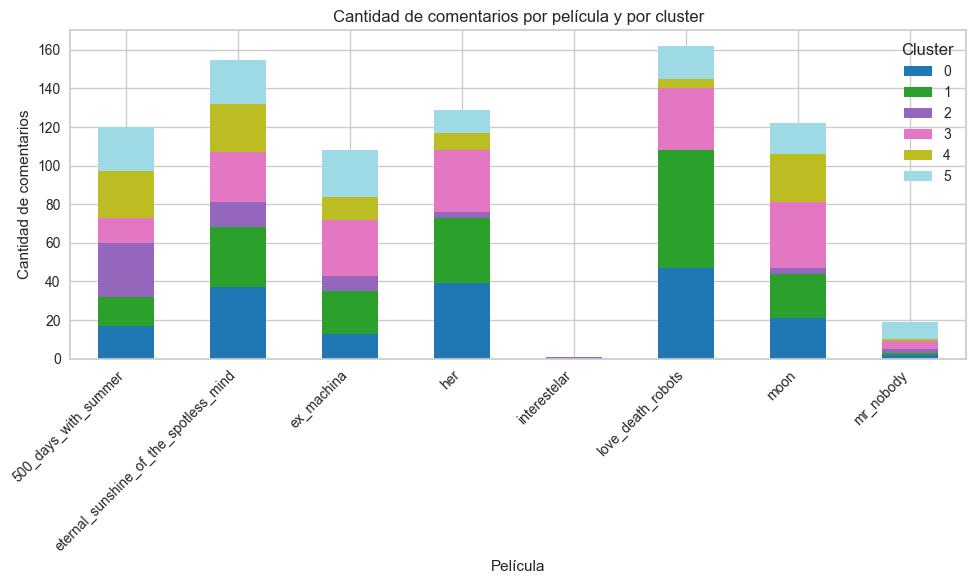

In [73]:
# Contar la cantidad de comentarios por película y por cluster (todos los clusters)
conteo_todos = df_sin_outliers.groupby(['Movie', 'clusters']).size().unstack(fill_value=0)

# Graficar
conteo_todos.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Cantidad de comentarios por película y por cluster')
plt.xlabel('Película')
plt.ylabel('Cantidad de comentarios')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

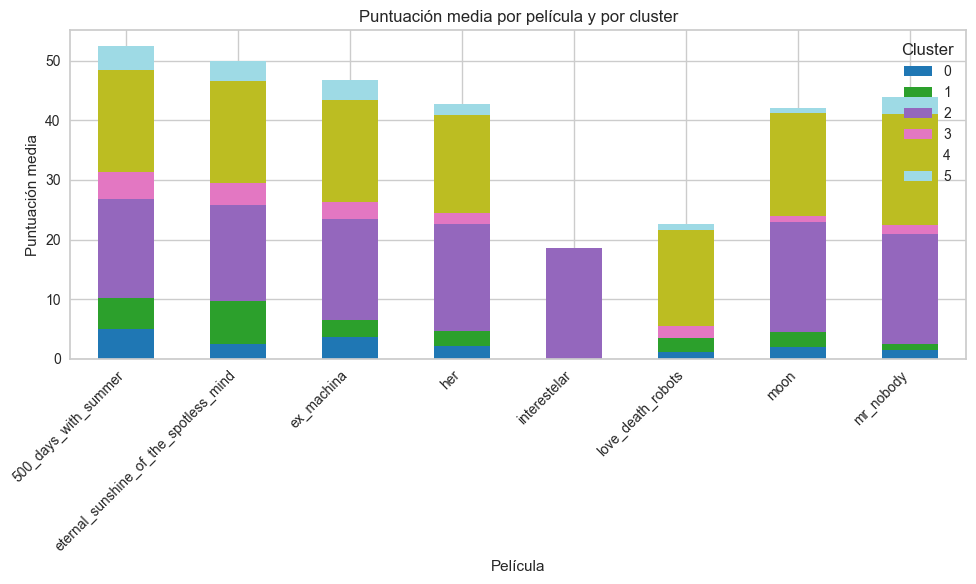

In [74]:
# Calcular la puntuación media por película y por cluster
puntaje_por_pelicula_cluster = df_sin_outliers.groupby(['Movie', 'clusters'])['Puntaje'].mean().unstack(fill_value=0)

# Graficar
puntaje_por_pelicula_cluster.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Puntuación media por película y por cluster')
plt.xlabel('Película')
plt.ylabel('Puntuación media')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

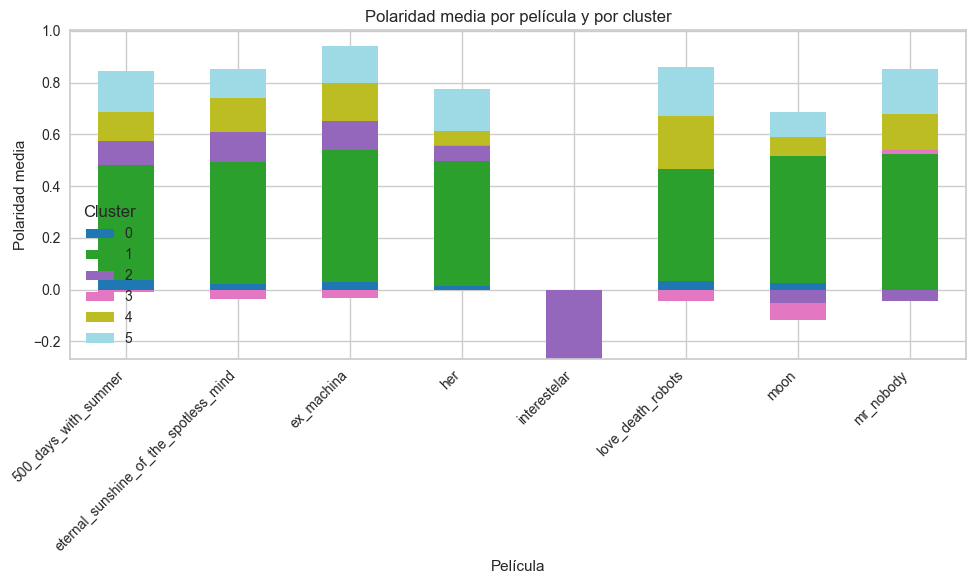

In [75]:
# Calcular la polaridad media por película y por cluster
polaridad_por_pelicula_cluster = df_sin_outliers.groupby(['Movie', 'clusters'])['Polarity'].mean().unstack(fill_value=0)

# Graficar
polaridad_por_pelicula_cluster.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Polaridad media por película y por cluster')
plt.xlabel('Película')
plt.ylabel('Polaridad media')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()